In [10]:
import sys

In [11]:
sys.path.append('..')

In [12]:
from Libraries_plot import *
from Framework.Diagram_Optimal_Window_Selection import *

In [13]:
def montecarlo_stuff(static_val,ppf_val=0.7):
    static_val = static_val.clip(min=0)
                    
            # # Save results of the test model with validation dataset 
            


    dist_load_forecasted = scipy.stats.norm(loc=static_val.mean(axis=-1),
                                        scale=static_val.std(axis=-1))


    # upper_load_forecasted = dist_load_forecasted.ppf(0.7) 
    upper_load_forecasted = dist_load_forecasted.ppf(ppf_val) 

    upper_load_forecasted[np.where(np.isnan(upper_load_forecasted))] = (
    static_val[np.where(np.isnan(upper_load_forecasted))][:, 0])
    return upper_load_forecasted

In [14]:
def load_scalers(city, ppf_static, ppf_helper,delay,phi):
    ''' Load the scalers for the static and shared data.'''
   
    static_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Th_{delay}/block_1_minmaxscaler.pkl'), 'rb'))
    shared_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/block_2_minmaxscaler.pkl'), 'rb'))
    return static_scaler, shared_scaler


def denormalize_normalize_static_shared(static,shared, static_scaler,shared_scaler, mae_forecasting, real_data, test_index_start):
    ''' Denormalize the static data using the scaler. '''
    static_denorm = static_scaler.inverse_transform(static) # Static = block 1
    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared, axis=-1)) # Shared = block 2
    mae_denorm = np.zeros(mae_forecasting.shape) # MAE = helper
    for i in range(B):
        mae_denorm[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm / 10e9 # Shared = block 2
    static_norm = static_denorm / 10e9 # Static = block 1
    mae_norm = mae_denorm / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data

    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff

    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

    return static_norm, shared_norm, mae_norm, output_norm


def upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')

    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    ppf_2_static = .99
    ppf_2_helper = .99

    upper_cd_static = dist_cd.ppf(ppf_2_static) # Can be changed. If set to 0.5 = mean
    upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
        cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
    upper_cs_shared = dist_cs.ppf(ppf_2_helper) # Can be changed. If set to 0.5 = mean 
    upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
        cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

    return upper_cd_static, upper_cs_shared

def load_mae_forecasting(city,static_scaler):
    mae_forecasting = np.transpose(np.load(os.path.join(ROOT_DIR,f'./{results_path}/{city}/helper_forecasting_delay_1.npy')), (0,2,1))
    
    return mae_forecasting

def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [15]:
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [16]:
def fun_total_cost(output_norm,cplus,static_norm,shared_norm,city_df,alpha,num_services,phi):

    gamma = 2 # positive slope always fix
    
    cplus_denorm = cplus * 10e9 
    static_denorm = static_norm * 10e9
    shared_denorm = shared_norm * 10e9
    output_denorm = output_norm * 10e9

    # print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

    test_length=min(len(output_norm),len(shared_norm))
    # 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
    # It may change city by city
    #test_length = 1734

    delta_i = np.zeros((test_length, num_services)) 
    rho_i = np.zeros((test_length, num_services))

    indexes_under = np.where((static_denorm[:test_length] - output_denorm[:test_length]) > 0)
    indexes_above = np.where((static_denorm[:test_length] - output_denorm[:test_length]) < 0)

    # Where the real load is below the allocated static, delta_i is equal to the real load.
    # In this case rho_i is equal to 0.

    for idx, element in enumerate(indexes_under[0]):
        delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

    # Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
    # In this case rho_i is equal to the difference between real load and static allocated.
        
    for idx, element in enumerate(indexes_above[0]):
        delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx]]
        rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                                - static_denorm[element, indexes_above[1][idx]])
        
    cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                                - output_denorm[:test_length]).sum() * gamma

    # Amount of capacity overprovisioned, i.e. higher than real output

    overprovisioning = (static_denorm[:test_length]
                        + cplus_denorm.T[:test_length] - output_denorm[:test_length]).clip(min=0)

    # Cost of the overprovisioning.
    # It includes the leftover shared capacity that have been provided by block 2 but not used by block 3.
    # The total cost is normalized by the total real load.
    # cost_overprovisioning = ((overprovisioning.sum()
    #                         + (shared_denorm[:test_length] - cplus_denorm.T[:test_length]).clip(min=0).sum())
    #                         * gamma / cost_normalization_factor)
    


    cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services

    cost_overprovisioning = ((overprovisioning.sum()
                            + (shared_denorm[:test_length] -cplus_all).clip(min=0).sum())
                            * gamma / cost_normalization_factor)
    
    cost_overprovisioning_static = (overprovisioning.sum() * gamma / cost_normalization_factor)
    cost_overprovisioning_shared = ((shared_denorm[:test_length] -cplus_all).clip(min=0).sum()
                            * gamma / cost_normalization_factor)

    slas = np.zeros((test_length, num_services))

    # Where the shared allocated is below rho_i it means that the real load is higher than the total capacity, i.e., slas violation

    slas[np.where((cplus_denorm.T[:test_length] - rho_i) < 0)] += 1

    # The cost of slas is equal to the total number of slas per app multiplied by the max load value of each app multiplied by alpha.

    # The cost is then normalized as for the overprovisioning.
    max_concatenated= city_df.max(axis=0)

    cost_slas = (slas.sum(axis=0) * alpha * max_concatenated / cost_normalization_factor).sum()


    eta = 2 # cost of instantiation

    delta_static = static_denorm[:test_length] - np.roll(static_denorm[:test_length], 1,axis=0)
    delta_static[0] = static_denorm[0]
    delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis=0)
    delta_shared[0] = cplus_denorm.T[0]

    cost_instantiation_static = np.zeros((test_length, num_services))
    cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

    cost_instantiation_shared = np.zeros((test_length, num_services))

    cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

    cost_instantiation = (cost_instantiation_static.sum()
                        + cost_instantiation_shared.sum()) / cost_normalization_factor

    reconfiguration = np.zeros((test_length, num_services))
    reconfiguration[np.where(delta_shared != 0)] = phi * rho_i[np.where(delta_shared != 0)]

    cost_reconfiguration = reconfiguration.sum() / cost_normalization_factor

    total_cost = cost_overprovisioning + cost_slas + cost_instantiation + cost_reconfiguration

    return total_cost, cost_overprovisioning , cost_slas , cost_instantiation , cost_reconfiguration,slas.sum(axis=0),cost_overprovisioning_static, cost_overprovisioning_shared

In [17]:
def select_cplus_np(cplus_df):
    cplus_df_sel=cplus_df.iloc[:,5:10]
    cplus_df_sel_np=cplus_df_sel.T.to_numpy()
    return cplus_df_sel_np

In [18]:
def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start

In [19]:
def cost_slas_analysis(city,ppf_helper,ppf_static,phi,alpha,delay,results_path,save_raw_data=False):
        # print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}')
        csv_path=f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'
        # print(csv_path)
        
        if os.path.exists(csv_path):
                test_index_start=fun_test_index_start(city,delay)
              
                cplus_df=pd.read_csv(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                cplus_df_sel_np=select_cplus_np(cplus_df)
                
                static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi)
                real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
                static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                

                # length=min(static_norm.shape[0],shared_norm.shape[0],output_norm.shape[0])
                # print(f'static_norm.shape: {static_norm.shape}, shared_norm.shape: {shared_norm.shape}, output_norm.shape: {output_norm.shape},mae_norm_shape: {mae_norm.shape}')
                # print(length)
                total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas ,cost_overprovisioning_static, cost_overprovisioning_shared = fun_total_cost(output_norm,cplus_df_sel_np,static_norm,shared_norm,real_data,alpha,num_services,phi)
                
                if save_raw_data:
                        if not os.path.exists(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}'):
                                os.makedirs(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}')
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy',static_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy',shared_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/mae_norm.npy',mae_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy',output_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy',slas)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy',cost_overprovisioning_static)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy',cost_overprovisioning_shared)
                #print(f'Total cost: {total_costs}, SLAS: {slas_sum} for city {city} with ppf_static {ppf_static} and ppf_helper {ppf_helper} amd phi {phi} and alpha {alpha}')
        else:
                total_cost=np.nan
                cost_slas=np.ones(num_services)*np.nan
                cost_overprovisioning=np.nan
                cost_instantiation=np.nan
                cost_reconfiguration=np.nan
                slas=[np.nan,np.nan,np.nan,np.nan,np.nan]
                
                
                #print('File not exist')
        return total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas


In [20]:
### Skip warnings
import warnings
warnings.filterwarnings("ignore")

In [21]:
def df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list):
    df_costs=pd.DataFrame({'total_costs':total_costs_list,'cost_overprovisioning':cost_overprovisioning_list,'cost_slas':cost_slas_list,'cost_instantiation':cost_instantiation_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)
    return df_costs

In [22]:

LOOKBACK = 6 # History given as input to the network. Could be modified if needed

gamma = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper

#B = 100 # Number of montecarlo output

#ppf_helper = 0.75 # Percentile of the helper
#ppf_static = 0.1 # Percentile of the static model
lookback = 6
num_services = 5
#delay = 6
B = 100
#test_index_start = 2016*8 + delay   # First sample start at test + 6.
# phi = 0.1 # negative slope block 1
# alpha = 0.75 # step of block 2
# city = 'Bordeaux'
# ppf_static = 0.9
# ppf_helper = 0.99





# ppf_helper_list=[0.5,0.65,0.70,0.75,0.9,0.95,0.99]
# # ppf_helper_list=[0.99]
# ppf_static_list=[0.2,0.3,0.5,0.75,0.9]
# # ppf_static_list=[0.75]

# ppf_helper_list=[0.99]
# ppf_static_list=[0.99]

# ppf_helper_list=[0.7,0.75,0.8,0.85,0.9,0.95,0.99]
# ppf_helper_list=[0.99]
# ppf_static_list=[0.7,0.75,0.8,0.85,0.9,0.95,0.99]
# ppf_static_list=[0.9]

# ppf_helper_list=[0.7]
# ppf_static_list=[0.7]

# ppf_helper_list=[0.55,0.6,0.65,0.7,0.9,0.99]

# ppf_helper_list=[0.9]
ppf_helper_list=[0.7,0.9,0.99]
ppf_static_list=[0.7,0.9,0.99]

# ppf_helper_list=[0.7]
# ppf_static_list=[0.9,0.99]

# ppf_helper_list=[0.6,0.65,0.7,.75,0.9,0.99]
# ppf_helper_list=[0.75]
# ppf_helper_list=[0.5,0.55,0.6,0.65]

# ppf_helper_list=[0.99]
# ppf_static_list=[0.6,0.65,0.7,.75,0.9,0.99]



# ppf_helper_list=[0.75] ##### AZTEC PAPER PPF's
# ppf_static_list=[0.1,0.5] ##### AZTEC PAPER PPF's

SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
PHIS = [0.1,1,10] # Negative slope of the loss function TO BE MODIFIED 
# PHIS=[0.1]
cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']

cities = ['Paris']

# ALPHAS=[2,3,5]
ALPHAS=[2,3,5]

# TB_Fpath=f'Training_block_new_mean_tesT_'
# results_path='results_new_mean_test_'

# TB_Fpath = 'TEST_4_H'
# TB_Fpath = 'Training_FIX_INSTANTATION'
# results_path = 'results_mix_match'

# results_path = 'Results_100_sim'
# results_path = 'Results_100_sim_bounds_2_100'
# results_path = 'results_TEST_4_H_mean'
# results_path = 'results_TEST_4_H_mean'
# results_path = 'Results_AZTEC_6'
# results_path = 'Results_Pipeline'
#ALPHAS=[0.75]


# TB_Fpath = 'Training_FIX_INSTANTATION'
# results_path = 'Results_INSTANTATION_FIX'
results_path = 'Results_Optimal_Cities_denorm'
# sergi_data/AZTEC_extension/


# ppf_static_list=[0.9]
# ppf_helper_list=[0.6,0.65,0.7,.75,0.9,0.99]
# # ppf_helper_list=[0.75]
# # ppf_helper_list=[0.5,0.55,0.6,0.65]

# # ppf_helper_list=[0.99]
# ppf_static_list=[0.6,0.65,0.7,.75,0.9,0.99]


total_costs_list=[]
cost_overprovisioning_list=[]
cost_slas_list=[]
cost_instantiation_list=[]
cost_reconfiguration_list=[]


save_raw_data=True

sla_perc_list_index_list=[]
slas_count_list=[]
for city in cities:
    for ppf_helper in (ppf_helper_list):
        for ppf_static in (ppf_static_list):
            for phi in (PHIS):
                for alpha in (ALPHAS):
                    
                    
                    if results_path=='Results_old':
                        delay=6
                    elif results_path=='Results_AZTEC_6':
                        delay=5
                    else:
                        delay=np.load (f'{results_path}/{city}/PHI_{phi}/ETA_2/overall_optimal_window.npy')
                    # print(f' Delay {delay}')
                    total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas=cost_slas_analysis(city,ppf_helper,ppf_static,phi,alpha,delay,results_path,save_raw_data)
                    total_costs_list.append(total_cost)
                    cost_slas_list.append(cost_slas)
                    cost_overprovisioning_list.append(cost_overprovisioning)
                    cost_instantiation_list.append(cost_instantiation)
                    cost_reconfiguration_list.append(cost_reconfiguration)
                    sla_perc_list_index=f'{city}_ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_alpha_{alpha}_delay_{delay}'
                    sla_perc_list_index_list.append(sla_perc_list_index)
                    slas_count_list.append(slas)
                   

FileNotFoundError: [Errno 2] No such file or directory: 'Results_Optimal_Cities_denorm/Paris/PHI_0.1/ETA_2/overall_optimal_window.npy'

In [73]:
phi=0.1
results_path = 'Results_INSTANTATION_FIX'
# results_path = 'Results_AZTEC_6'
delay=np.load (f'{results_path}/{city}/PHI_{phi}/overall_optimal_window.npy')
# delay = 5
test_index_start=fun_test_index_start(city,delay)
ppf_static = 0.99
ppf_helper = 0.7
alpha= 2
              
cplus_df=pd.read_csv(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
cplus_df_sel_np=select_cplus_np(cplus_df)

static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi)
real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
              

In [74]:
output_norm.shape

(3561, 5)

In [75]:

cplus_denorm = cplus_df_sel_np * 10e9 
static_denorm = static_norm * 10e9
shared_denorm = shared_norm * 10e9
output_denorm = output_norm * 10e9

# print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

test_length=min(len(output_norm),len(shared_norm))
# 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
# It may change city by city
#test_length = 1734

delta_i = np.zeros((test_length, num_services)) 
rho_i = np.zeros((test_length, num_services))

indexes_under = np.where((static_denorm[:test_length] - output_denorm[:test_length]) > 0)
indexes_above = np.where((static_denorm[:test_length] - output_denorm[:test_length]) < 0)

# Where the real load is below the allocated static, delta_i is equal to the real load.
# In this case rho_i is equal to 0.

for idx, element in enumerate(indexes_under[0]):
    delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

# Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
# In this case rho_i is equal to the difference between real load and static allocated.
    
for idx, element in enumerate(indexes_above[0]):
    delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx]]
    rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                            - static_denorm[element, indexes_above[1][idx]])
    
cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                            - output_denorm[:test_length]).sum() * gamma

# Amount of capacity overprovisioned, i.e. higher than real output

overprovisioning = (static_denorm[:test_length]
                    + cplus_denorm.T[:test_length] - output_denorm[:test_length]).clip(min=0)

cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services

cost_overprovisioning = ((overprovisioning.sum()
                        + (shared_denorm[:test_length] -cplus_all).clip(min=0).sum())
                        * gamma / cost_normalization_factor)

slas = np.zeros((test_length, num_services))

# Where the shared allocated is below rho_i it means that the real load is higher than the total capacity, i.e., slas violation

slas[np.where((cplus_denorm.T[:test_length] - rho_i) < 0)] += 1

# The cost of slas is equal to the total number of slas per app multiplied by the max load value of each app multiplied by alpha.

# The cost is then normalized as for the overprovisioning.
max_concatenated= real_data.max(axis=0)

cost_slas = (slas.sum(axis=0) * alpha * max_concatenated / cost_normalization_factor).sum()


eta = 2 # cost of instantiation

delta_static = static_denorm[:test_length] - np.roll(static_denorm[:test_length], 1,axis=0)
delta_static[0] = static_denorm[0]
delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis = 0)
delta_shared[0] = cplus_denorm.T[0]

cost_instantiation_static = np.zeros((test_length, num_services))
cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

cost_instantiation_shared = np.zeros((test_length, num_services))

cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

cost_instantiation = (cost_instantiation_static.sum()
                    + cost_instantiation_shared.sum()) / cost_normalization_factor

reconfiguration = np.zeros((test_length, num_services))
reconfiguration[np.where(delta_shared != 0)] = phi * rho_i[np.where(delta_shared != 0)]

cost_reconfiguration = reconfiguration.sum() / cost_normalization_factor

In [69]:
delta_shared.shape

(3575, 5)

In [76]:
reconfiguration.sum()/cost_normalization_factor

0.0021341642879031063

In [71]:
reconfiguration.sum()/cost_normalization_factor

0.0004068348817185194

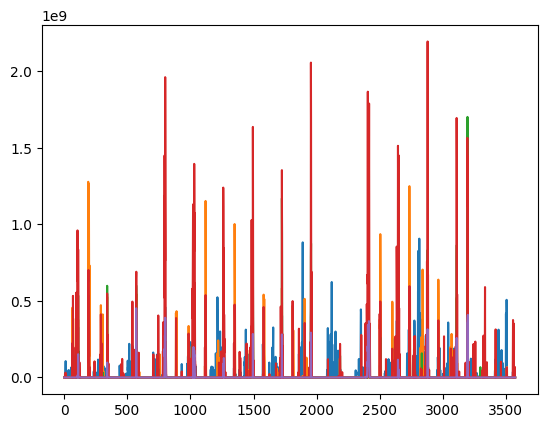

In [68]:
plt.plot(reconfiguration)

In [160]:

cost_instantiation_static = np.zeros((test_length, num_services))
cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

cost_instantiation_shared = np.zeros((test_length, num_services))

cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

cost_instantiation = (cost_instantiation_static.sum()
                    + cost_instantiation_shared.sum()) / cost_normalization_factor

In [105]:
cplus_df_sel_np_all =cplus_df_sel_np.T.sum(axis=1)

In [106]:
cplus_df_sel_np_all.shape

(3561,)

In [107]:
static_norm_all = static_norm.sum(axis=1)
shared_norm_all=shared_norm.reshape(-1)+static_norm_all
output_dorm_all=output_norm.sum(axis=1)
cplus_df_sel_np_all_plotly= cplus_df_sel_np_all+static_norm_all

In [113]:
static_norm_all.shape

(3561,)

In [114]:
output_dorm_all.shape

(3561,)

In [108]:
important = pd.DataFrame({'Static:':static_norm_all,'Real':output_dorm_all,'Shared':shared_norm_all,'Cplus':cplus_df_sel_np_all_plotly})

In [109]:
import plotly.express as px

In [110]:
fig = px.line(important, title=f'Load for {city} with delay {delay} and phi {phi}')

In [111]:
fig.write_html(f'Result_{city}_load_delay_{delay}_phi_{phi}_new.html')

In [112]:
shared_norm=shared_norm.reshape(-1)

In [21]:
df_costs_=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [22]:
df_costs_[df_costs_.index.str.contains('alpha_2_delay_21')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.362719,0.243622,0.084623,0.032099,0.002376
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.359680,0.213751,0.112632,0.030905,0.002393


In [23]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.362719,0.243622,0.084623,0.032099,0.002376
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.410093,0.267032,0.107636,0.033042,0.002382
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.479820,0.297160,0.146948,0.033352,0.002361
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_18,0.378470,0.298603,0.056837,0.017225,0.005805
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_18,0.414431,0.319986,0.070095,0.017735,0.006616
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_18,0.466408,0.344543,0.096801,0.018294,0.006770
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.399759,0.352514,0.006963,0.039312,0.000970
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.403179,0.352774,0.010012,0.039313,0.001079
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.411339,0.355199,0.015745,0.039316,0.001079
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.359680,0.213751,0.112632,0.030905,0.002393


In [14]:
df_costs_[df_costs_.index.str.contains('alpha_2_delay_21')].idxmin()

total_costs              Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_a...
cost_overprovisioning    Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_a...
cost_slas                Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_a...
cost_instantiation       Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_a...
cost_reconfiguration     Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_a...
dtype: object

In [15]:
df_costs_.to_csv(f'FINAL_RESULTS_PARIS/Costs_{city}_delay_{delay}_phi_{phi}_AZTEC_EXT_RESULTS.csv')

In [25]:
df_costs_[df_costs_['cost_slas']==df_costs_['cost_slas'].min()]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_2_delay_4,0.424653,0.351368,0.004251,0.063183,0.00585


In [15]:
df_costs_[df_costs_.index.str.contains('0.99_ppf_helper_0.7_')]

NameError: name 'df_costs_' is not defined

In [24]:
df_costs__AZTEC_OLD=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [26]:
df_costs__AZTEC_OLD.to_csv(f'FINAL_RESULTS_PARIS/Costs_{city}_delay_{delay}_phi_{phi}_AZTEC_RESULTS_Diff_Loss.csv')

In [74]:
df_costs__AZTEC_OLD[df_costs__AZTEC_OLD.index.str.contains('static_0.5_ppf_helper_0.75_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.5_ppf_helper_0.75_phi_0.1_alpha_2_delay_5,0.311155,0.236250,0.022412,0.052093,0.000400
Paris_ppf_static_0.5_ppf_helper_0.75_phi_0.1_alpha_3_delay_5,0.326197,0.242603,0.031000,0.052194,0.000400
Paris_ppf_static_0.5_ppf_helper_0.75_phi_0.1_alpha_5_delay_5,0.355327,0.257177,0.045782,0.051969,0.000398
Paris_ppf_static_0.5_ppf_helper_0.75_phi_1_alpha_2_delay_5,0.320796,0.259043,0.010816,0.050179,0.000757
Paris_ppf_static_0.5_ppf_helper_0.75_phi_1_alpha_3_delay_5,0.332742,0.265585,0.016185,0.050216,0.000757
Paris_ppf_static_0.5_ppf_helper_0.75_phi_1_alpha_5_delay_5,0.349449,0.273847,0.024606,0.050239,0.000757
Paris_ppf_static_0.5_ppf_helper_0.75_phi_10_alpha_2_delay_5,0.422593,0.363460,0.005138,0.050624,0.003371
Paris_ppf_static_0.5_ppf_helper_0.75_phi_10_alpha_3_delay_5,0.426988,0.365339,0.007780,0.050498,0.003371
Paris_ppf_static_0.5_ppf_helper_0.75_phi_10_alpha_5_delay_5,0.433714,0.367390,0.012364,0.050589,0.003371


In [36]:
df_costs__AZTEC_OLD[df_costs__AZTEC_OLD.index.str.contains('Paris')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_5,0.560542,0.157444,0.055823,0.346863,0.000412


In [63]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.683678,0.274912,0.066025,0.340583,0.002158
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.727577,0.303190,0.080435,0.341793,0.002158
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.797597,0.333333,0.120183,0.341918,0.002162
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.627211,0.256252,0.012923,0.356974,0.001063
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.644326,0.270187,0.016020,0.357055,0.001063
...,...,...,...,...,...
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.641565,0.264458,0.019059,0.356983,0.001066
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_5_delay_7,0.669261,0.286068,0.025056,0.357070,0.001066
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.724442,0.352145,0.006829,0.363249,0.002218
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.731917,0.356629,0.009760,0.363260,0.002269


In [ ]:
sla_perc_list_index_list

In [75]:
SLA_list =pd.DataFrame(slas_count_list,index=sla_perc_list_index_list)

In [76]:
SLA_list

,0,1,2,3,4
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,88.0,128.0,112.0,194.0,30.0
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,72.0,109.0,90.0,151.0,30.0
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,63.0,99.0,69.0,134.0,40.0
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7,43.0,24.0,16.0,33.0,6.0
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7,31.0,21.0,13.0,27.0,7.0
...,...,...,...,...,...
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_3_delay_7,38.0,25.0,16.0,33.0,6.0
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_5_delay_7,30.0,14.0,15.0,26.0,7.0
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_2_delay_7,31.0,18.0,9.0,8.0,7.0
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_3_delay_7,27.0,16.0,10.0,8.0,7.0


In [77]:
df_costs_21= df_costs_[df_costs_.index.str.contains('alpha_2_delay_21')]

In [78]:
df_costs_21

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.683678,0.274912,0.066025,0.340583,0.002158
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.670275,0.246701,0.082330,0.339077,0.002167
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.664179,0.214947,0.110656,0.336409,0.002166
Paris_ppf_static_0.7_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,0.702159,0.305379,0.053036,0.341584,0.002160
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,0.683914,0.276060,0.065343,0.340345,0.002165
Paris_ppf_static_0.99_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,0.665656,0.238336,0.086758,0.338400,0.002162
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.742202,0.348277,0.049791,0.341968,0.002166
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.702699,0.304133,0.055013,0.341388,0.002164
Paris_ppf_static_0.99_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.678407,0.265418,0.070937,0.339886,0.002166


In [115]:
df_costs_[df_costs_.index.str.contains('_static_0.7_ppf_helper_0.99_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.742202,0.348277,0.049791,0.341968,0.002166
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_3_delay_21,0.784478,0.381515,0.058751,0.342049,0.002163
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_5_delay_21,0.857196,0.430133,0.082946,0.341965,0.002153
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_2_delay_7,0.669919,0.302815,0.009036,0.357004,0.001064
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.688189,0.318676,0.011336,0.357111,0.001066
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_5_delay_7,0.719359,0.343287,0.017917,0.357088,0.001066
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.743999,0.373064,0.005294,0.363372,0.002269
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.755282,0.382857,0.006823,0.363372,0.002230
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_5_delay_7,0.773642,0.398984,0.008996,0.363393,0.002269


In [79]:
df_costs_21[df_costs_21['cost_slas']==df_costs_21['cost_slas'].min()]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.742202,0.348277,0.049791,0.341968,0.002166


In [ ]:
SLA_list_perc=SLA_list[SLA_list.index.str.contains('static_0.7_ppf_helper_0.99')]

In [ ]:
SLA_list_perc.iloc[:3,:]=SLA_list.iloc[:3,:]/3561
SLA_list_perc.iloc[3:6,:]=SLA_list.iloc[3:6,:]/3570
SLA_list_perc.iloc[6:9,:]=SLA_list.iloc[6:9,:]/3570

In [80]:
SLA_list[SLA_list.index.str.contains('static_0.7_ppf_helper_0.99')]

,0,1,2,3,4
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,66.0,109.0,88.0,132.0,29.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_3_delay_21,62.0,80.0,64.0,104.0,27.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_5_delay_21,54.0,82.0,45.0,85.0,24.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_2_delay_7,24.0,13.0,14.0,25.0,5.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_3_delay_7,22.0,13.0,9.0,21.0,4.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_5_delay_7,21.0,12.0,7.0,21.0,4.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_2_delay_7,20.0,12.0,8.0,7.0,7.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_3_delay_7,10.0,9.0,8.0,8.0,7.0
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_5_delay_7,5.0,4.0,8.0,7.0,7.0


In [91]:
SLA_list_perc

,0,1,2,3,4
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.024712,0.035945,0.031452,0.054479,0.008425
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_3_delay_21,0.020219,0.030609,0.025274,0.042404,0.008425
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_5_delay_21,0.017692,0.027801,0.019377,0.037630,0.011233
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_2_delay_7,0.012045,0.006723,0.004482,0.009244,0.001681
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.008683,0.005882,0.003641,0.007563,0.001961
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_5_delay_7,0.007003,0.003081,0.003922,0.007283,0.001401
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.008403,0.003922,0.002521,0.001961,0.001961
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.006443,0.003361,0.002241,0.001961,0.001961
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_5_delay_7,0.004482,0.002521,0.002241,0.001961,0.001681


In [93]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.7_ppf_helper_0.99_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,0.742202,0.348277,0.049791,0.341968,0.002166
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_3_delay_21,0.784478,0.381515,0.058751,0.342049,0.002163
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_5_delay_21,0.857196,0.430133,0.082946,0.341965,0.002153
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_2_delay_7,0.669919,0.302815,0.009036,0.357004,0.001064
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.688189,0.318676,0.011336,0.357111,0.001066
Paris_ppf_static_0.7_ppf_helper_0.99_phi_1_alpha_5_delay_7,0.719359,0.343287,0.017917,0.357088,0.001066
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.743999,0.373064,0.005294,0.363372,0.002269
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.755282,0.382857,0.006823,0.363372,0.002230
Paris_ppf_static_0.7_ppf_helper_0.99_phi_10_alpha_5_delay_7,0.773642,0.398984,0.008996,0.363393,0.002269


In [20]:

delta_i = np.zeros((test_length, num_services)) 
rho_i = np.zeros((test_length, num_services))

indexes_under = np.where((static_denorm[:test_length] - output_denorm[:test_length]) > 0)
indexes_above = np.where((static_denorm[:test_length] - output_denorm[:test_length]) < 0)

# Where the real load is below the allocated static, delta_i is equal to the real load.
# In this case rho_i is equal to 0.


NameError: name 'test_length' is not defined

In [13]:
city = 'Paris'
fpath=f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_ETA_TEST/{city}/'

In [23]:
PHI = 0.1

In [24]:
Simulations= 10

In [29]:
cities = ['Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice',  'Reims', 'Rennes', 'Strasbourg']

In [ ]:
sergi_data/AZTEC_extension/Training_Block_Optimal_Cities_loss_RAW

In [49]:
optimal_all = []
optimal_list= []
for city in cities:
        fpath=f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Optimal_Cities_loss_RAW/{city}/'
        optimal_all = []
        for Simulation in range( Simulations):
        
                
                Fpath=f'{fpath}/PHI_{PHI}/ETA_2/Simulation_{Simulation}/optimal_window.npy'
                optimal_window=np.load(Fpath)
                optimal_all.append(int(optimal_window))
        optimal_list.append(optimal_all)


In [50]:
aaaa = pd.DataFrame(optimal_list)

In [51]:
aaaa = aaaa.T

In [52]:
aaaa.columns = cities

In [53]:
aaaa

,Dijon,Grenoble,Lille,Lyon,Marseille,Montpellier,Nantes,Nice,Reims,Rennes,Strasbourg
0,4,74,4,20,20,20,4,4,4,4,52
1,4,71,4,20,20,24,4,4,13,20,57
2,4,71,20,4,20,68,20,4,13,4,61
3,4,59,20,4,5,20,4,4,23,4,55
4,4,57,13,20,5,20,20,4,4,4,55
5,4,71,4,20,5,23,20,4,4,4,55
6,20,61,16,23,20,52,23,4,4,20,61
7,4,71,16,20,5,24,20,68,13,4,55
8,4,63,16,4,5,20,25,4,4,20,63
9,4,68,16,20,20,23,20,61,4,20,63


In [43]:
aaaa

,Bordeaux,Dijon,Grenoble,Lille,Lyon,Marseille,Montpellier,Nantes,Nice,Reims,Rennes,Strasbourg,Toulouse
0,27,23,61,4,4,3,20,25,4,4,4,48,22
1,22,4,74,4,23,20,68,23,68,13,4,55,18
2,27,4,80,4,20,6,68,20,20,4,4,71,18
3,71,23,86,20,20,18,52,4,4,4,4,63,18
4,54,4,63,16,20,5,68,20,4,4,4,52,12
5,27,4,71,20,20,18,68,20,4,4,7,4,20
6,27,4,71,13,20,20,68,20,68,4,4,63,5
7,22,4,61,20,20,20,20,20,4,13,20,57,18
8,20,20,71,4,20,20,4,20,4,4,20,65,12
9,27,4,71,4,4,6,25,20,4,13,20,74,22


In [44]:
len(optimal_list)

13

In [45]:
optimal_all

[22, 18, 18, 18, 12, 20, 5, 18, 12, 22]

In [46]:
aaa=np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/Results_100_sim/Paris/PHI_10/overall_optimal_window.npy')
aaa

array(5)

In [36]:
config={}

In [37]:
config['PHI']=0.1
config['city']='Paris'

In [38]:
PHI = 0.1

In [39]:
Simulations =10

In [40]:
fpath

'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Optimal_Cities_loss_RAW/Strasbourg/'

In [41]:
def parse_val_loss(config, fpath,Simulations,ETA):    
    optimall_windo_list=[]
    optimal_all = []
    opttimal_val_loss=[]

    
    city=config['city']
    PHI=config['PHI']

    for Simulation in range( Simulations):

        
        Fpath=f'{fpath}/PHI_{PHI}/ETA_{ETA}/Simulation_{Simulation}/optimal_window.npy'
        optimal_window=np.load(Fpath)
        optimal_all.append(optimal_window)

        optimal_int=int(optimal_window)

        pred_fpath=f'{fpath}/PHI_{PHI}/ETA_{ETA}/Simulation_{Simulation}/Th_{optimal_int}/training_block1_delay_{optimal_int}_phi_{PHI}_gamma_2_deltax_005.npy'
        pred=np.load(pred_fpath)
        pred_montecarlo=montecarlo_stuff(pred,ppf_val=0.7)
        x_val_norm_towindow,minmaxscaler=load_city_val_norm(config)

        val_loss= denorm_validation_loss(pred_montecarlo, x_val_norm_towindow, minmaxscaler,PHI,ETA)

        optimall_windo_list.append(int(optimal_window))
        opttimal_val_loss.append(val_loss)
        
       

    return optimall_windo_list,opttimal_val_loss

In [15]:
fpath

NameError: name 'fpath' is not defined

In [42]:
PHIS = [0.1,1,10]

In [43]:
config={}
config['PHI']=0.1
config['city']='Reims'
Simulations = 10

In [44]:
colors = ['b','g','r']

In [45]:
fpath=f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_ETA_TEST/Paris/'

In [46]:
ETA = 2

In [25]:
cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']

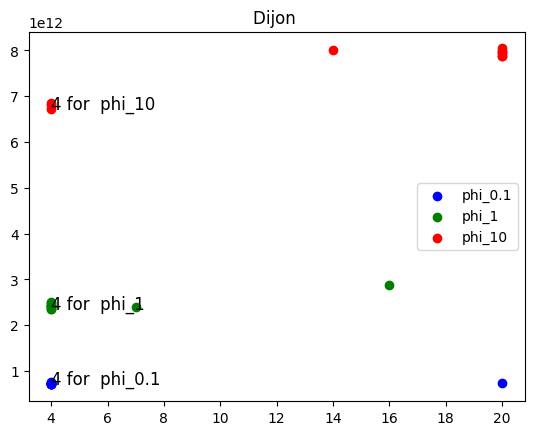

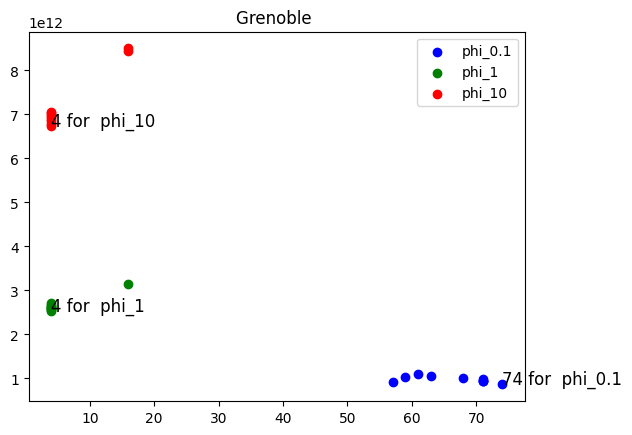

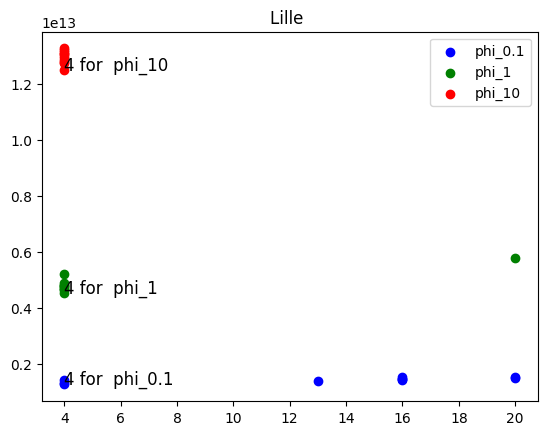

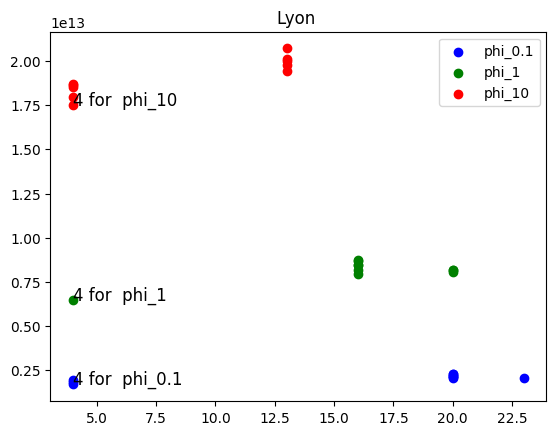

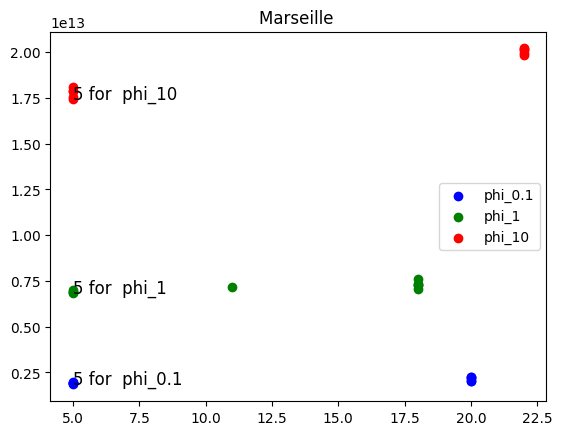

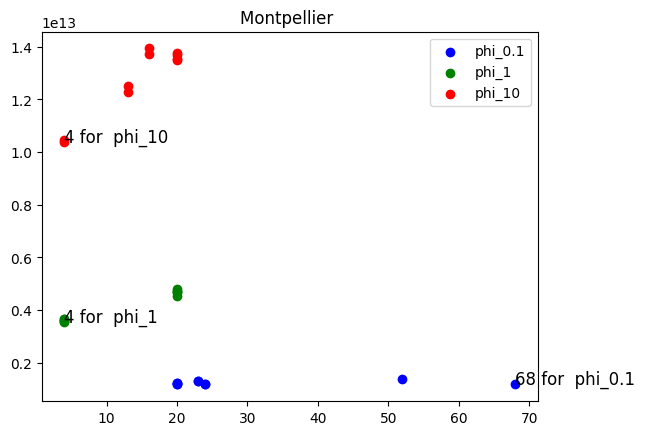

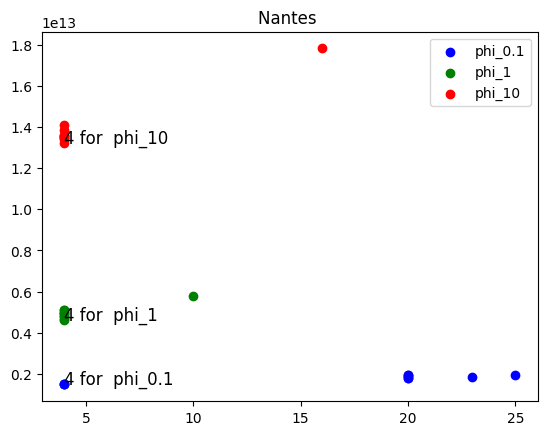

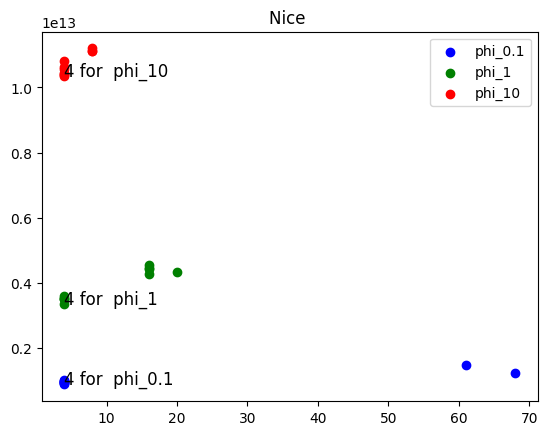

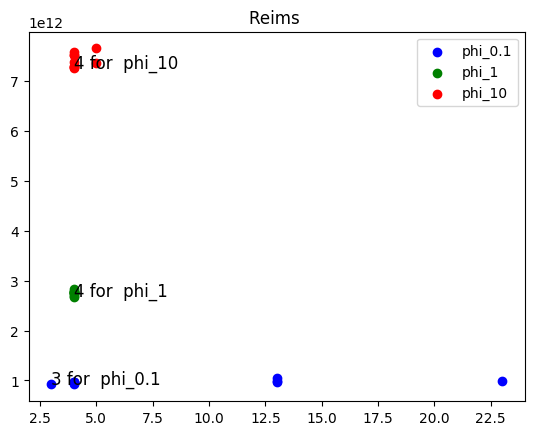

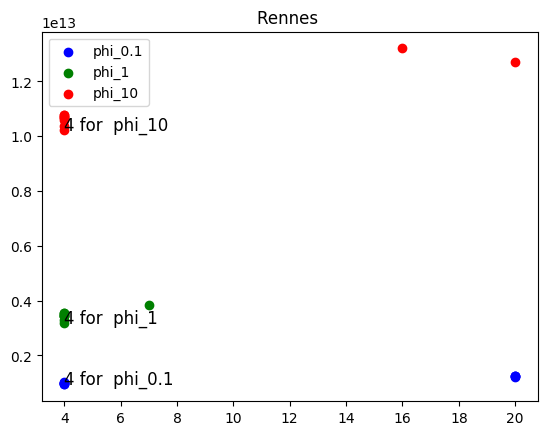

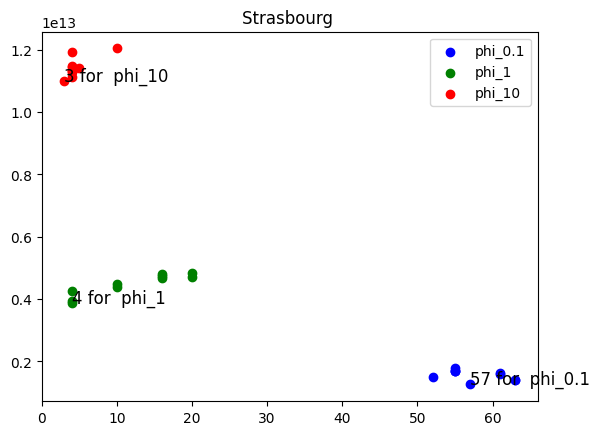

In [48]:
# cities = ['Paris']
PHIS = [0.1,1,10]
for city in cities:
    fpath = f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Optimal_Cities_loss_RAW/{city}/'
    config['city']=city
    
    plt.figure()
    for i,phi in enumerate(PHIS):
        config['PHI']=phi
   
        optimal_window, val_loss =parse_val_loss(config,fpath,Simulations,ETA)
        
        aa =pd.DataFrame({'val_loss':val_loss},index=optimal_window)
        
    
        plt.scatter(aa.index,aa.values,label=f'phi_{phi}',color=colors[i])
        #text showing what is the minimum value
        plt.text(aa.idxmin(),aa.min(),f'{aa.idxmin().values[0]} for  phi_{phi}',fontsize=12)
    plt.title(f'{city} ')
    plt.legend()

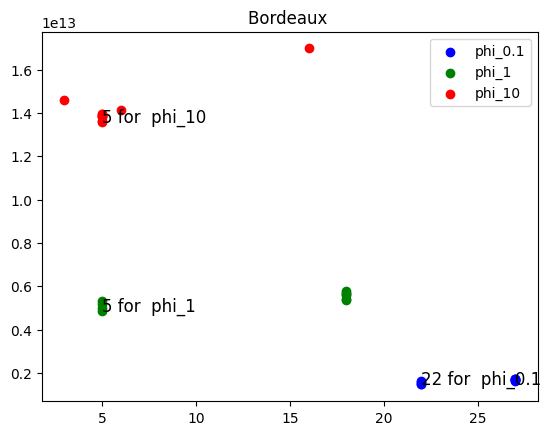

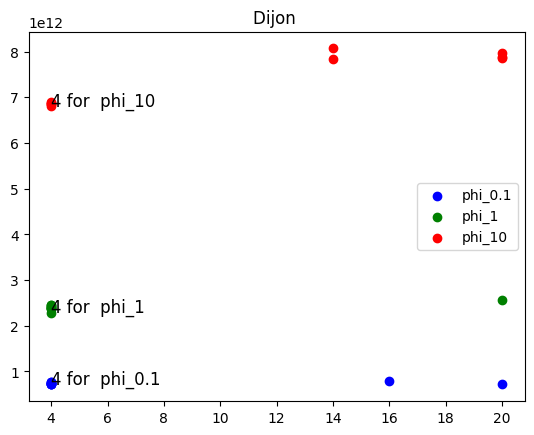

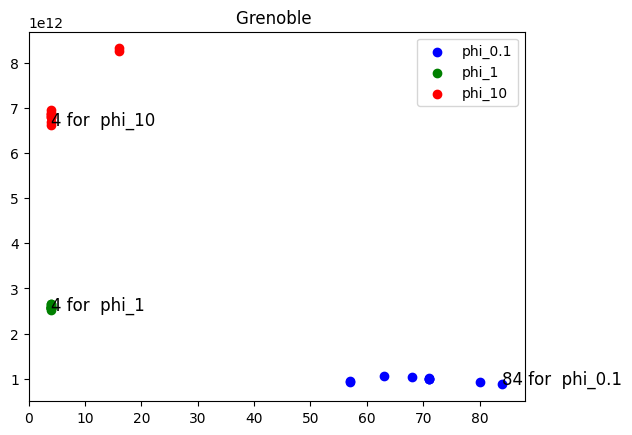

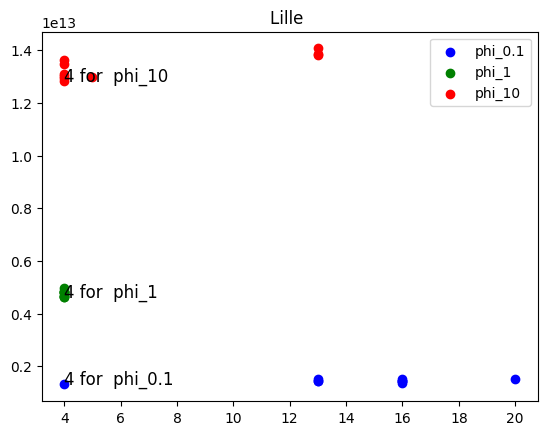

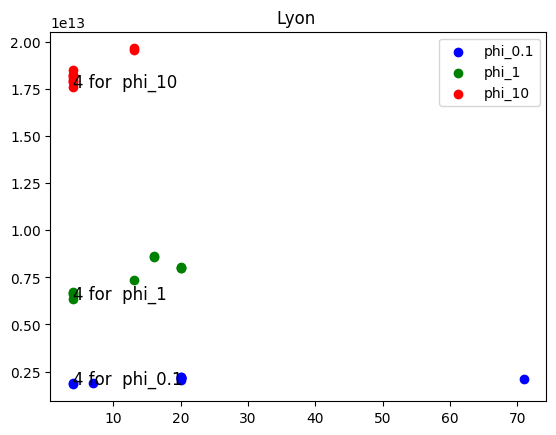

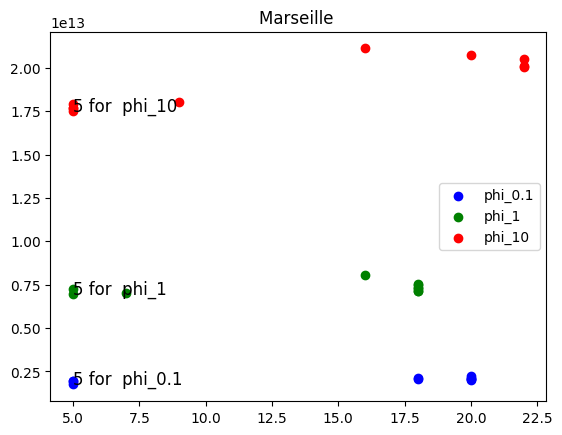

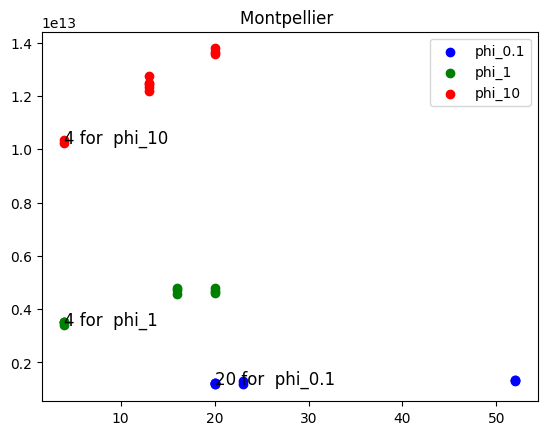

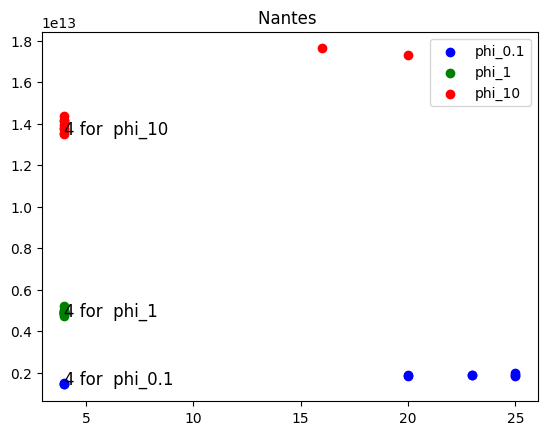

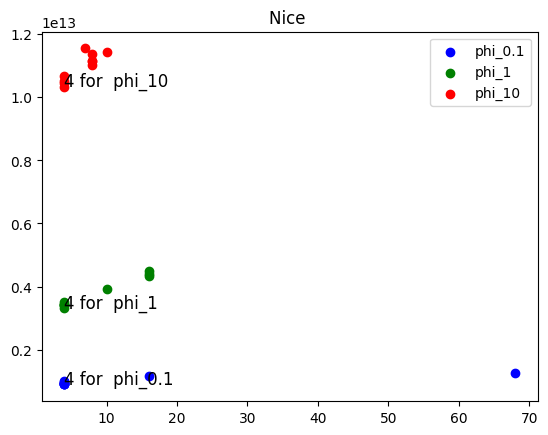

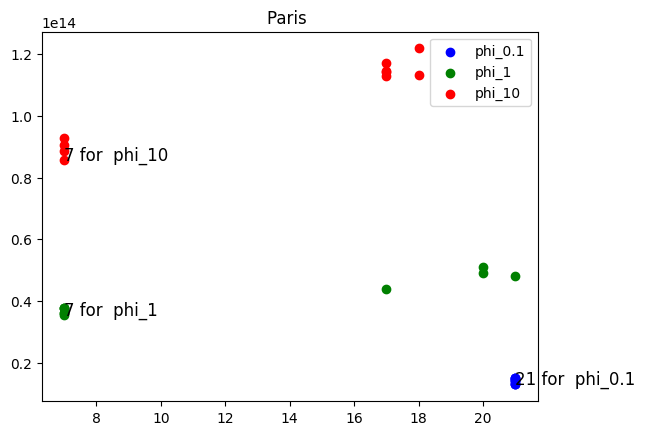

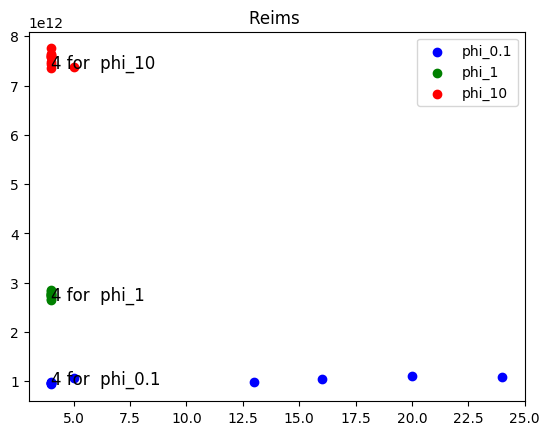

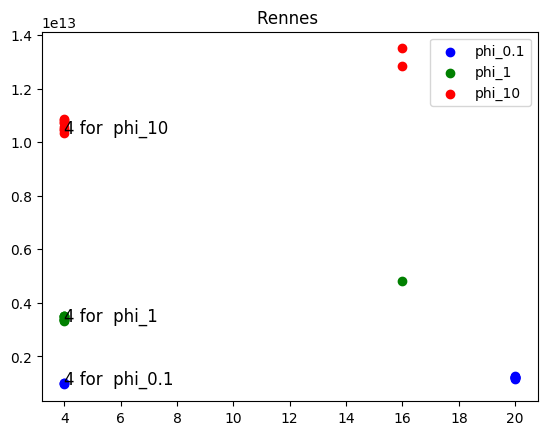

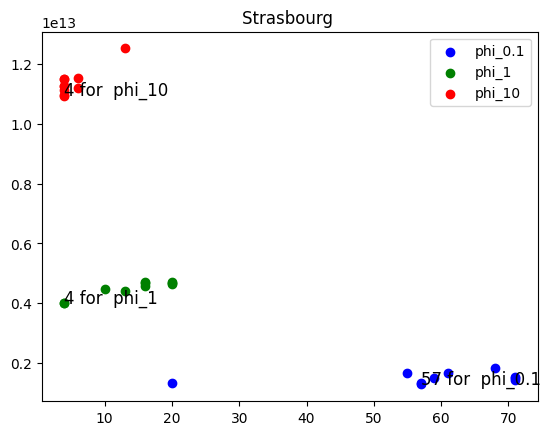

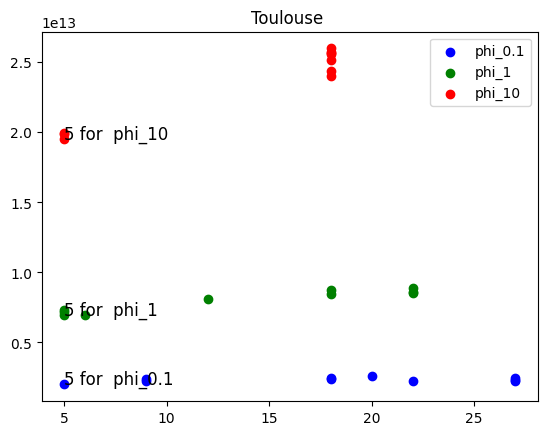

In [26]:
# cities = ['Paris']
PHIS = [0.1,1,10]
for city in cities:
    fpath = f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Optimal_Cities/{city}/'
    config['city']=city
    
    plt.figure()
    for i,phi in enumerate(PHIS):
        config['PHI']=phi
   
        optimal_window, val_loss =parse_val_loss(config,fpath,Simulations,ETA)
        
        aa =pd.DataFrame({'val_loss':val_loss},index=optimal_window)
        
    
        plt.scatter(aa.index,aa.values,label=f'phi_{phi}',color=colors[i])
        #text showing what is the minimum value
        plt.text(aa.idxmin(),aa.min(),f'{aa.idxmin().values[0]} for  phi_{phi}',fontsize=12)
    plt.title(f'{city} ')
    plt.legend()
    # plt.savefig(f'./FIGS/Optimal_Windows/{city}_optimal_window.png')

In [ ]:
cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']
PHIS = [0.1]
for city in cities:
    fpath = f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Optimal_Cities/{city}/'
    config['city']=city
    
    plt.figure()
    for i,phi in enumerate(PHIS):
        config['PHI']=phi
   
        optimal_window, val_loss =parse_val_loss(config,fpath,Simulations,ETA)
        
        aa =pd.DataFrame({'val_loss':val_loss},index=optimal_window)
        
    
        plt.scatter(aa.index,aa.values,label=f'phi_{phi}',color=colors[i])
        #text showing what is the minimum value
        plt.text(aa.idxmin(),aa.min(),f'{aa.idxmin().values[0]} for  phi_{phi}',fontsize=12)
    plt.title(f'{city} ')
    plt.legend()
    # plt.savefig(f'./FIGS/Optimal_Windows/{city}_optimal_window.png')

In [56]:
config={}
config['PHI']=0.1
config['city']='Paris'

cities = ['Paris']
ETAS = [2,10,20]
PHIS = [0.1,1,10]
Simulations = 10

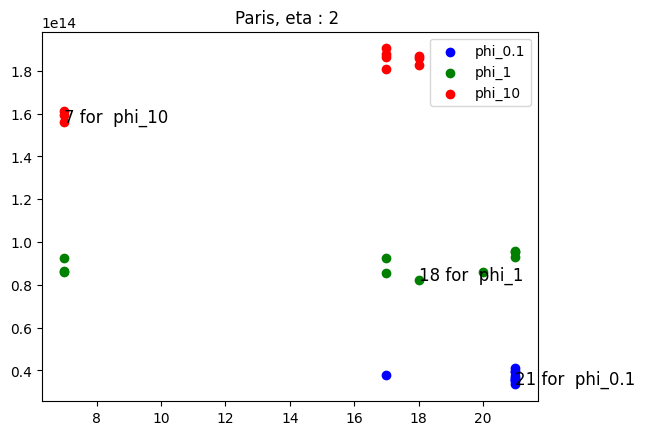

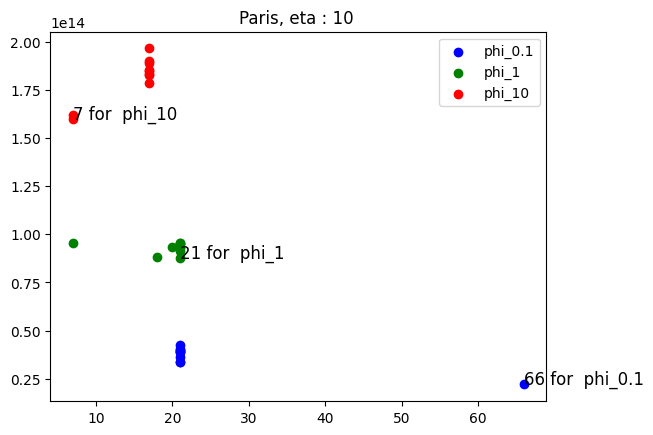

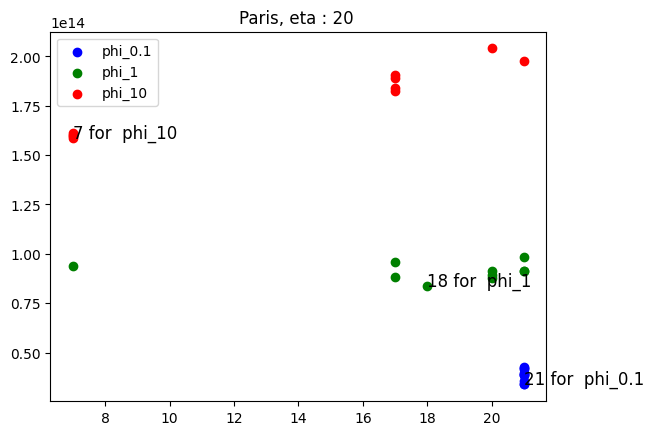

In [58]:

for city in cities:
    fpath = f'/home/sergi_alcala/sergi_data/AZTEC_extension/Training_Block_Different_Loss/{city}/'
    config['city']=city
    for eta in ETAS:
        plt.figure()
        for i,phi in enumerate(PHIS):
            config['PHI']=phi
    
            optimal_window, val_loss =parse_val_loss(config,fpath,Simulations,eta)
            
            aa =pd.DataFrame({'val_loss':val_loss},index=optimal_window)
            
        
            plt.scatter(aa.index,aa.values,label=f'phi_{phi}',color=colors[i])
            #text showing what is the minimum value
            plt.text(aa.idxmin(),aa.min(),f'{aa.idxmin().values[0]} for  phi_{phi}',fontsize=12)
        plt.title(f'{city}, eta : {eta} ')
        plt.legend()
        # plt.savefig(f'./FIGS/Optimal_Windows/{city}_optimal_window.png')

In [34]:
ETA = 2

In [35]:
optimal_window, val_loss =parse_val_loss(config,fpath,Simulations,ETA)

In [36]:
optimal_window

[21, 21, 21, 21, 21, 17, 21, 21, 21, 21]

In [37]:
val_loss

[39982760540404.01,
 36702255093450.04,
 39434474267264.36,
 35469376817382.055,
 36079271574369.52,
 37860517378573.87,
 41137771216782.03,
 37459405049573.07,
 33459116218631.906,
 34982358001326.516]

In [76]:
aa =pd.DataFrame({'val_loss':val_loss},index=optimal_window)

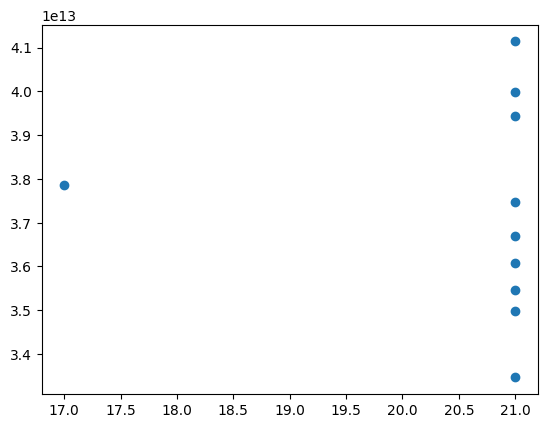

In [77]:
plt.scatter(aa.index,aa.values)

In [10]:
def select_optimal_window(optimall_windo_list,opttimal_val_loss):

    df=pd.DataFrame(opttimal_val_loss).T
    df.columns=optimall_windo_list
    opt_window=int(df.idxmin(axis=1))
    print(f'Optimal window is {opt_window}')
    
    return opt_window,df

In [125]:
opt_wind, df = select_optimal_window(optimal_window,val_loss)

Optimal window is 7


In [126]:
df

,18,18,17,17,7,17,18,7,17,7
0,1.860067e+14,1.868489e+14,1.880367e+14,1.808993e+14,1.595268e+14,1.904311e+14,1.828389e+14,1.613911e+14,1.862592e+14,1.560888e+14


In [127]:
df.idxmin(axis=1)

0    7
dtype: int64

Text(0.5, 1.0, 'Validation loss vs window size for PHI=10')

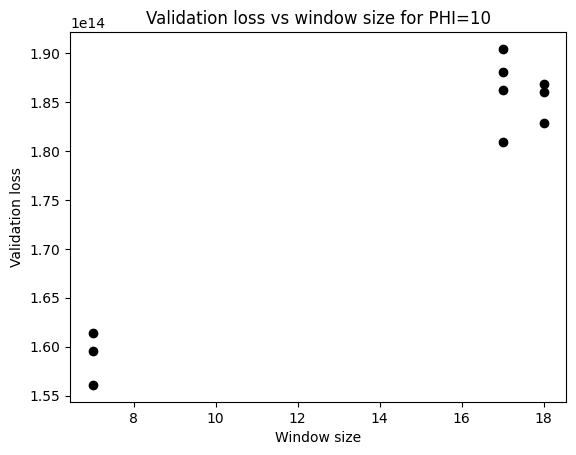

In [128]:
plt.plot(optimal_window, val_loss, 'o', color='black')
plt.xlabel('Window size')
plt.ylabel('Validation loss')
plt.title(f'Validation loss vs window size for PHI={config["PHI"]}')

In [55]:
optimal_window, val_loss =parse_val_loss(config, fpath,PHI,Simulations)

NameError: name 'PHI' is not defined

Text(0.5, 1.0, 'Validation loss vs window size for PHI=0.1')

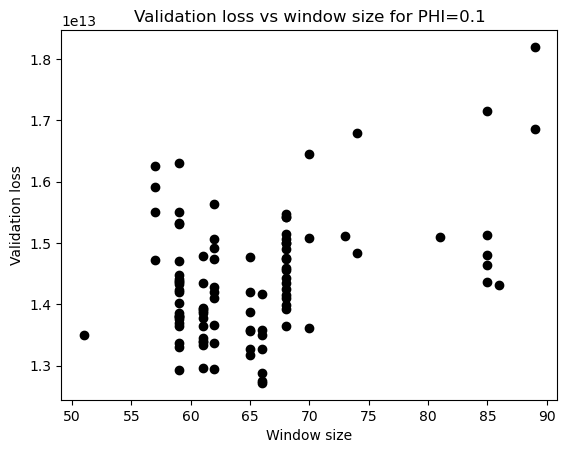

In [33]:
plt.plot(optimal_window, val_loss, 'o', color='black')
plt.xlabel('Window size')
plt.ylabel('Validation loss')
plt.title('Validation loss vs window size for PHI=0.1')

In [15]:
optimal_window

NameError: name 'optimal_window' is not defined

Text(0.5, 1.0, 'Validation loss vs window size for PHI=0.1')

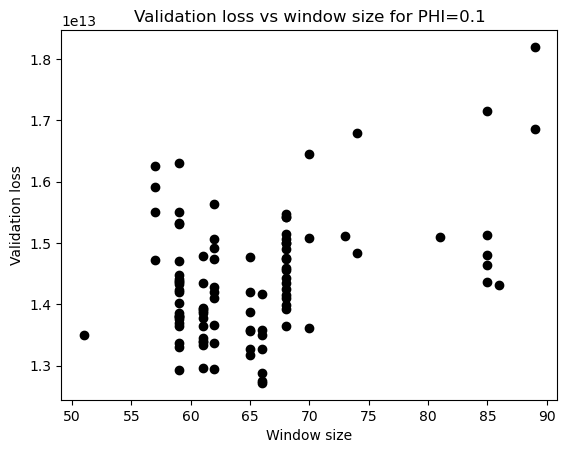

In [38]:
plt.plot(optimal_window, val_loss, 'o', color='black')
plt.xlabel('Window size')
plt.ylabel('Validation loss')
plt.title('Validation loss vs window size for PHI=0.1')

In [128]:
pd.DataFrame(optimal_all)

,0
0,74.821130
1,71.899945
2,81.089868
3,74.999180
4,85.214695
5,85.504621
6,85.572759
7,74.546045
8,74.546045
9,81.787327


In [39]:
pd.DataFrame(optimal_all)

,0
0,65.612692
1,66.650287
2,74.398484
3,62.188044
4,85.646492
...,...
95,68.267496
96,66.707817
97,59.191988
98,81.099076


In [11]:
aaaa = np.array(46)

In [91]:
np.save('/home/sergi_alcala/sergi_data/AZTEC_extension/Test_lengths/Paris/PHI_1/overall_optimal_window.npy',aaaa)

In [26]:
slas_count_list

[array([263., 263., 292., 361., 205.]),
 array([244., 243., 270., 314., 208.]),
 array([240., 237., 244., 290., 220.]),
 array([138.,  63.,  43.,  91.,  15.]),
 array([136.,  62.,  43.,  92.,  15.]),
 array([134.,  60.,  43.,  92.,  15.]),
 array([46., 21., 12., 19.,  7.]),
 array([45., 20., 12., 18.,  7.]),
 array([44., 20., 12., 18.,  7.]),
 array([303., 327., 314., 418., 223.]),
 array([290., 292., 284., 368., 221.]),
 array([260., 268., 280., 338., 206.]),
 array([139.,  66.,  48.,  98.,  15.]),
 array([134.,  62.,  45.,  94.,  15.]),
 array([133.,  62.,  43.,  92.,  15.]),
 array([56., 29., 16., 19.,  7.]),
 array([50., 23., 14., 19.,  7.]),
 array([47., 23., 15., 19.,  7.]),
 array([354., 371., 346., 572., 240.]),
 array([318., 351., 326., 490., 231.]),
 array([295., 320., 287., 418., 210.]),
 array([156.,  82.,  55., 108.,  15.]),
 array([148.,  79.,  55., 103.,  15.]),
 array([140.,  71.,  50.,  96.,  15.]),
 array([64., 42., 18., 20.,  7.]),
 array([63., 37., 18., 19.,  7.]),


In [28]:
263/3561

0.07385565852288684

In [29]:
total_cost

0.7550051153293316

In [30]:
slas_count_list=np.array(slas_count_list)

In [31]:
slas_df= pd.DataFrame(slas_count_list)

In [32]:
sla_perc_list_index_list

['Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_5_delay_7',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_2_delay_7',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_3_delay_7',
 'Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_5_delay_7',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_7',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_7',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_7',
 'Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alph

In [33]:
total_costs_list_df=pd.DataFrame(total_costs_list)

In [34]:
total_costs_list_df.index=sla_perc_list_index_list

In [35]:
total_costs_list_df.columns=['total_costs']

In [36]:
total_costs_list_df[total_costs_list_df.index.str.contains('phi_0.1_alpha_2')].min()

total_costs    0.784412
dtype: float64

In [18]:
total_costs_list_df.to_csv('total_costs_list_df.csv')

In [37]:
slas_df

,0,1,2,3,4
0,263.0,263.0,292.0,361.0,205.0
1,244.0,243.0,270.0,314.0,208.0
2,240.0,237.0,244.0,290.0,220.0
3,138.0,63.0,43.0,91.0,15.0
4,136.0,62.0,43.0,92.0,15.0
...,...,...,...,...,...
76,131.0,62.0,43.0,92.0,15.0
77,131.0,60.0,43.0,91.0,15.0
78,49.0,22.0,15.0,19.0,7.0
79,46.0,20.0,13.0,18.0,7.0


In [38]:
slas_perc_row_01=slas_df.iloc[0:3,:] /3501
slas_perc_row_1=slas_df.iloc[3:6,:] /3536
slas_perc_row_10=slas_df.iloc[6:9,:] /3575


In [39]:
slas_perc_row_01

,0,1,2,3,4
0,0.075121,0.075121,0.083405,0.103113,0.058555
1,0.069694,0.069409,0.077121,0.089689,0.059412
2,0.068552,0.067695,0.069694,0.082833,0.062839


In [40]:
slas_perc_row_1

,0,1,2,3,4
3,0.039027,0.017817,0.012161,0.025735,0.004242
4,0.038462,0.017534,0.012161,0.026018,0.004242
5,0.037896,0.016968,0.012161,0.026018,0.004242


In [41]:
slas_perc_row_10

,0,1,2,3,4
6,0.012867,0.005874,0.003357,0.005315,0.001958
7,0.012587,0.005594,0.003357,0.005035,0.001958
8,0.012308,0.005594,0.003357,0.005035,0.001958


In [42]:
#concat the two df
slas_perc=pd.concat([slas_perc_row_01,slas_perc_row_1,slas_perc_row_10],axis=0)

In [43]:
slas_perc #### SLA PERCENTAGE for previous TimeSeries Alignment Columns == Services, Rows == Different configurations
slas_perc.index=sla_perc_list_index_list

ValueError: Length mismatch: Expected axis has 9 elements, new values have 81 elements

In [56]:
slas_perc ### SLA PERCENTAGE for current TimeSeries Alignment

,0,1,2,3,4
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_2_delay_69,0.073693,0.105684,0.193373,0.267067,0.113396
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_3_delay_69,0.065124,0.095116,0.165096,0.227078,0.093402
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_5_delay_69,0.060268,0.082262,0.119109,0.168809,0.069694
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_2_delay_45,0.161482,0.256505,0.242364,0.298360,0.184106
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_3_delay_45,0.149604,0.222851,0.212670,0.260747,0.161482
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_5_delay_45,0.136878,0.204186,0.191459,0.224548,0.145362
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_2_delay_5,0.012308,0.003636,0.002238,0.002797,0.001399
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_3_delay_5,0.012308,0.003636,0.002238,0.002797,0.001399
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_5_delay_5,0.012028,0.003636,0.002238,0.002797,0.001399


In [109]:
slas_perc ### SLA PERCENTAGE for current TimeSeries Alignment

,0,1,2,3,4
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_2_delay_81,0.113396,0.199657,0.288775,0.442159,0.264781
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_3_delay_81,0.101114,0.177949,0.250214,0.398172,0.223650
Paris_ppf_static_0.85_ppf_helper_0.85_phi_0.1_alpha_5_delay_81,0.090260,0.153385,0.218223,0.317052,0.191088
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_2_delay_46,0.185238,0.271210,0.252545,0.354072,0.169683
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_3_delay_46,0.147907,0.236143,0.216912,0.299491,0.141403
Paris_ppf_static_0.85_ppf_helper_0.85_phi_1_alpha_5_delay_46,0.128959,0.195136,0.180713,0.254808,0.117930
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_2_delay_5,0.011189,0.003357,0.001678,0.002238,0.001399
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_3_delay_5,0.011189,0.003357,0.001678,0.002238,0.001399
Paris_ppf_static_0.85_ppf_helper_0.85_phi_10_alpha_5_delay_5,0.011189,0.003077,0.001678,0.002238,0.001399


In [110]:
slas_count_list

array([[ 397.,  699., 1011., 1548.,  927.],
       [ 354.,  623.,  876., 1394.,  783.],
       [ 316.,  537.,  764., 1110.,  669.],
       [ 655.,  959.,  893., 1252.,  600.],
       [ 523.,  835.,  767., 1059.,  500.],
       [ 456.,  690.,  639.,  901.,  417.],
       [  40.,   12.,    6.,    8.,    5.],
       [  40.,   12.,    6.,    8.,    5.],
       [  40.,   11.,    6.,    8.,    5.]])

In [111]:
slas_count_list

array([[ 397.,  699., 1011., 1548.,  927.],
       [ 354.,  623.,  876., 1394.,  783.],
       [ 316.,  537.,  764., 1110.,  669.],
       [ 655.,  959.,  893., 1252.,  600.],
       [ 523.,  835.,  767., 1059.,  500.],
       [ 456.,  690.,  639.,  901.,  417.],
       [  40.,   12.,    6.,    8.,    5.],
       [  40.,   12.,    6.,    8.,    5.],
       [  40.,   11.,    6.,    8.,    5.]])

In [112]:
slas_count_list.shape

(9, 5)

In [33]:
def df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list):
    df_costs=pd.DataFrame({'total_costs':total_costs_list,'cost_overprovisioning':cost_overprovisioning_list,'cost_slas':cost_slas_list,'cost_instantiation':cost_instantiation_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)
    return df_costs

In [34]:
df_costs_=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [35]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.909364,1.286009,0.301547,0.318864,0.002944
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,2.148931,1.396054,0.430579,0.319394,0.002905
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,2.573882,1.568723,0.681732,0.320511,0.002916
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.808721,0.442576,0.015086,0.349277,0.001783
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.859177,0.487260,0.020817,0.349324,0.001775
...,...,...,...,...,...
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.806006,0.431745,0.023214,0.349260,0.001787
Paris_ppf_static_0.99_ppf_helper_0.99_phi_1_alpha_5_delay_7,0.886206,0.501268,0.033875,0.349283,0.001780
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.735760,0.366102,0.006382,0.359764,0.003511
Paris_ppf_static_0.99_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.744963,0.377637,0.003896,0.359920,0.003511


In [19]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,2.067815,1.466841,0.277644,0.320411,0.002918
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3_delay_21,2.382908,1.669047,0.388966,0.321961,0.002934
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5_delay_21,2.813774,1.867134,0.622088,0.321632,0.002920
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2_delay_7,0.893303,0.528282,0.013971,0.349265,0.001785
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3_delay_7,0.958198,0.588226,0.018950,0.349237,0.001785
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5_delay_7,1.038959,0.655423,0.032531,0.349219,0.001786
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2_delay_7,0.755873,0.388162,0.004305,0.359895,0.003511
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_3_delay_7,0.776273,0.406894,0.005966,0.359902,0.003511
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_5_delay_7,0.823987,0.456000,0.004533,0.359943,0.003511


In [15]:
df_costs_[df_costs_.index.str.contains('_0.99_ppf_helper_0.65_phi_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.99_ppf_helper_0.65_phi_0.1_alpha_2_delay_21,1.545348,0.861659,0.365177,0.315551,0.002961
Paris_ppf_static_0.99_ppf_helper_0.65_phi_0.1_alpha_3_delay_21,1.822056,0.995418,0.506693,0.317002,0.002943
Paris_ppf_static_0.99_ppf_helper_0.65_phi_0.1_alpha_5_delay_21,2.258875,1.176332,0.760287,0.319306,0.002950
Paris_ppf_static_0.99_ppf_helper_0.65_phi_1_alpha_2_delay_7,0.629483,0.247455,0.031467,0.348772,0.001789
Paris_ppf_static_0.99_ppf_helper_0.65_phi_1_alpha_3_delay_7,0.664213,0.271848,0.041692,0.348886,0.001788
Paris_ppf_static_0.99_ppf_helper_0.65_phi_1_alpha_5_delay_7,0.723657,0.317889,0.054949,0.349029,0.001789
Paris_ppf_static_0.99_ppf_helper_0.65_phi_10_alpha_2_delay_7,0.725686,0.354912,0.007642,0.359621,0.003511
Paris_ppf_static_0.99_ppf_helper_0.65_phi_10_alpha_3_delay_7,0.729058,0.359018,0.006709,0.359819,0.003511
Paris_ppf_static_0.99_ppf_helper_0.65_phi_10_alpha_5_delay_7,0.735304,0.361573,0.010395,0.359825,0.003511


In [51]:
df_costs_[df_costs_.index.str.contains('phi_0.1_alpha_2')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.562756,1.062618,0.168377,0.328994,0.002768
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.415843,0.890008,0.196413,0.326651,0.002770
Paris_ppf_static_0.99_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.293254,0.732179,0.235074,0.323237,0.002763
Paris_ppf_static_0.7_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,1.686396,1.198013,0.15522,0.330398,0.002765
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,1.526511,1.019757,0.175727,0.328269,0.002758
Paris_ppf_static_0.99_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Paris_ppf_static_0.7_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,1.896196,1.417205,0.145014,0.331209,0.002768
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,1.713863,1.224358,0.156673,0.330060,0.002771
Paris_ppf_static_0.99_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN


In [62]:
df_costs_6=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [51]:
df_costs_.dropna(inplace=True)

In [91]:
deepcog_total_costs= [0.90304008, 1.03258006, 1.28240583, 1.12621791, 1.25608085,
       1.50624967, 3.35799612, 3.49108877, 3.74468809]

In [15]:
total_costs = df_costs_[df_costs_.index.str.contains('ppf_static_0.9_ppf_helper_0.9')]['total_costs']

In [26]:
df_costs_ = df_costs_[df_costs_.index.str.contains('ppf_static_0.9_ppf_helper_0.9')]

In [79]:
total_costs_index = total_costs.index

In [82]:
total_cost_ind_clean = []
for ind in total_costs_index:
     total_cost_ind_clean.append(ind.split('_0.75_')[1])

Text(0.5, 1.0, 'Total Cost Comparison between AZTEC with training block and Deepcog \n with Paris_ppf_static_0.99_ppf_helper_0.75')

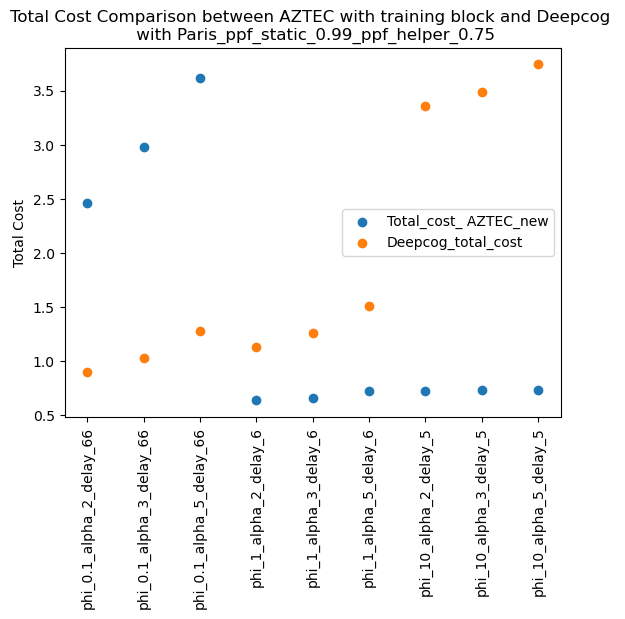

In [94]:
plt.scatter(total_cost_ind_clean,total_costs.values,label = 'Total_cost_ AZTEC_new')
plt.scatter(total_cost_ind_clean,deepcog_total_costs,label = 'Deepcog_total_cost')

plt.ylabel('Total Cost')
plt.xticks(rotation=90)
plt.legend()
plt.title('Total Cost Comparison between AZTEC with training block and Deepcog \n with Paris_ppf_static_0.99_ppf_helper_0.75')

In [83]:
total_cost_ind_clean

['phi_0.1_alpha_2_delay_66',
 'phi_0.1_alpha_3_delay_66',
 'phi_0.1_alpha_5_delay_66',
 'phi_1_alpha_2_delay_6',
 'phi_1_alpha_3_delay_6',
 'phi_1_alpha_5_delay_6',
 'phi_10_alpha_2_delay_5',
 'phi_10_alpha_3_delay_5',
 'phi_10_alpha_5_delay_5']

In [75]:
df_costs_[df_costs_.index.str.contains('ppf_static_0.99_ppf_helper_0.75')]['total_costs'].index

Index(['Paris_ppf_static_0.99_ppf_helper_0.75_phi_0.1_alpha_2_delay_66',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_0.1_alpha_3_delay_66',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_0.1_alpha_5_delay_66',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_1_alpha_2_delay_6',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_1_alpha_3_delay_6',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_1_alpha_5_delay_6',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_10_alpha_2_delay_5',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_10_alpha_3_delay_5',
       'Paris_ppf_static_0.99_ppf_helper_0.75_phi_10_alpha_5_delay_5'],
      dtype='object')

In [16]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.99_ppf_helper_0.9_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.99_ppf_helper_0.9_phi_0.1_alpha_2_delay_5,0.764315,0.361876,0.052119,0.350072,0.000248
Paris_ppf_static_0.99_ppf_helper_0.9_phi_0.1_alpha_3_delay_5,0.838598,0.418627,0.069397,0.350327,0.000248
Paris_ppf_static_0.99_ppf_helper_0.9_phi_0.1_alpha_5_delay_5,0.921708,0.462963,0.108105,0.350392,0.000248
Paris_ppf_static_0.99_ppf_helper_0.9_phi_1_alpha_2_delay_4,0.711264,0.344298,0.008409,0.358442,0.000116
Paris_ppf_static_0.99_ppf_helper_0.9_phi_1_alpha_3_delay_4,0.747369,0.376484,0.012308,0.358455,0.000122
Paris_ppf_static_0.99_ppf_helper_0.9_phi_1_alpha_5_delay_4,0.791281,0.412586,0.02012,0.358460,0.000116
Paris_ppf_static_0.99_ppf_helper_0.9_phi_10_alpha_2_delay_30,1.040544,0.603170,0.063229,0.356696,0.017448
Paris_ppf_static_0.99_ppf_helper_0.9_phi_10_alpha_3_delay_30,1.105283,0.638342,0.092626,0.356867,0.017448
Paris_ppf_static_0.99_ppf_helper_0.9_phi_10_alpha_5_delay_30,1.262875,0.742962,0.144961,0.357504,0.017448


In [33]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.9_ppf_helper_0.9_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,1.023974,0.532138,0.159173,0.329860,0.002803
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_3_delay_21,1.138728,0.573777,0.231930,0.330229,0.002792
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_5_delay_21,1.343752,0.660003,0.349161,0.331793,0.002796
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_2_delay_7,0.637264,0.244564,0.036302,0.355089,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_3_delay_7,0.690074,0.279639,0.054006,0.355123,0.001305
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_5_delay_7,0.777705,0.331514,0.089773,0.355109,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_2_delay_7,0.561733,0.186571,0.010706,0.362104,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_3_delay_7,0.584649,0.205251,0.014911,0.362136,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_5_delay_7,0.603508,0.214209,0.024852,0.362097,0.002351


In [29]:
df_costs_['cost_overprovisioning']=df_costs_['cost_overprovisioning']/2

In [31]:
df_costs_['total_costs'] = df_costs_['total_costs'] - df_costs_['cost_overprovisioning']

In [35]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,1.023974,0.532138,0.159173,0.329860,0.002803
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_3_delay_21,1.138728,0.573777,0.231930,0.330229,0.002792
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_5_delay_21,1.343752,0.660003,0.349161,0.331793,0.002796
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_2_delay_7,0.637264,0.244564,0.036302,0.355089,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_3_delay_7,0.690074,0.279639,0.054006,0.355123,0.001305
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_5_delay_7,0.777705,0.331514,0.089773,0.355109,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_2_delay_7,0.561733,0.186571,0.010706,0.362104,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_3_delay_7,0.584649,0.205251,0.014911,0.362136,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_5_delay_7,0.603508,0.214209,0.024852,0.362097,0.002351
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_21,1.087867,0.606580,0.147497,0.330989,0.002801


In [34]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.9_ppf_helper_0.9_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_21,1.023974,0.532138,0.159173,0.329860,0.002803
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_3_delay_21,1.138728,0.573777,0.231930,0.330229,0.002792
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_5_delay_21,1.343752,0.660003,0.349161,0.331793,0.002796
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_2_delay_7,0.637264,0.244564,0.036302,0.355089,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_3_delay_7,0.690074,0.279639,0.054006,0.355123,0.001305
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_5_delay_7,0.777705,0.331514,0.089773,0.355109,0.001309
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_2_delay_7,0.561733,0.186571,0.010706,0.362104,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_3_delay_7,0.584649,0.205251,0.014911,0.362136,0.002351
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_5_delay_7,0.603508,0.214209,0.024852,0.362097,0.002351


In [36]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.7_ppf_helper_0.7_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.909364,1.286009,0.301547,0.318864,0.002944
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,2.148931,1.396054,0.430579,0.319394,0.002905
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,2.573882,1.568723,0.681732,0.320511,0.002916
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.808721,0.442576,0.015086,0.349277,0.001783
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.859177,0.487260,0.020817,0.349324,0.001775
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_5_delay_7,0.937489,0.552678,0.033744,0.349280,0.001787
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.742960,0.374902,0.0047,0.359847,0.003511
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.750023,0.383101,0.003517,0.359895,0.003511
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.768419,0.398837,0.006114,0.359957,0.003511


In [15]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,1.550333,1.058469,0.158954,0.330116,0.002795
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,1.762458,1.209135,0.218961,0.331565,0.002797
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,2.046710,1.362947,0.349069,0.331889,0.002805
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_7,0.890399,0.497775,0.036248,0.355073,0.001303
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_7,0.978557,0.567825,0.054287,0.355140,0.001305
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_5_delay_7,1.107172,0.661132,0.089691,0.355040,0.001309
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.751720,0.377051,0.010199,0.362118,0.002351
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.794094,0.414824,0.014817,0.362100,0.002351
Paris_ppf_static_0.7_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.836655,0.447661,0.024540,0.362103,0.002351


In [17]:
df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.9_ppf_helper_0.9_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_2_delay_5,0.889555,0.496472,0.042522,0.350313,0.000247
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_3_delay_5,0.943424,0.529976,0.062932,0.350270,0.000247
Paris_ppf_static_0.9_ppf_helper_0.9_phi_0.1_alpha_5_delay_5,1.049747,0.610582,0.088497,0.350421,0.000247
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_2_delay_4,0.813442,0.447164,0.007695,0.358468,0.000116
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_3_delay_4,0.853747,0.483931,0.011226,0.358474,0.000116
Paris_ppf_static_0.9_ppf_helper_0.9_phi_1_alpha_5_delay_4,0.945030,0.568779,0.01764,0.358489,0.000122
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_2_delay_30,1.101905,0.666782,0.060593,0.357081,0.017448
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_3_delay_30,1.208090,0.746036,0.087112,0.357494,0.017448
Paris_ppf_static_0.9_ppf_helper_0.9_phi_10_alpha_5_delay_30,1.358218,0.844520,0.138285,0.357964,0.017448


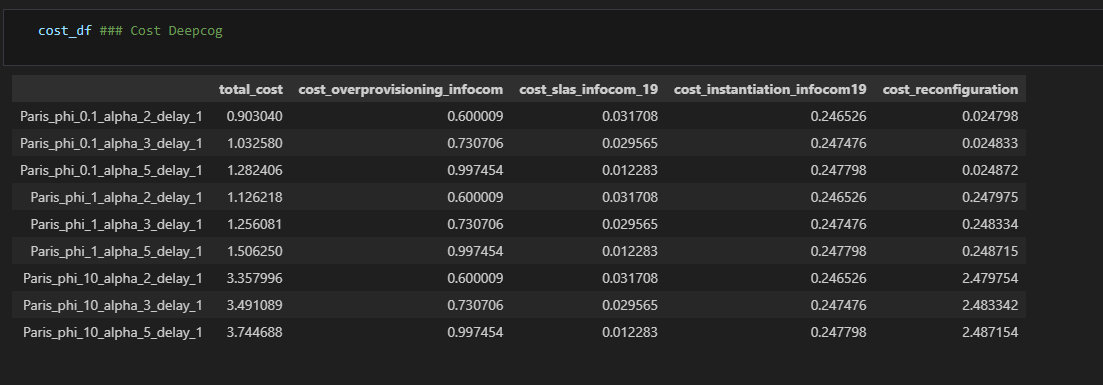

In [71]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_2_delay_69,2.729597,2.044213,0.390156,0.284015,0.011213
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_3_delay_69,3.048196,2.231292,0.518019,0.287778,0.011107
Paris_ppf_static_0.7_ppf_helper_0.7_phi_0.1_alpha_5_delay_69,3.540922,2.633406,0.600384,0.296126,0.011007
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_2_delay_45,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Paris_ppf_static_0.7_ppf_helper_0.7_phi_1_alpha_3_delay_45,2.246383,1.142313,0.754078,0.304689,0.045304
...,...,...,...,...,...
Paris_ppf_static_0.95_ppf_helper_0.95_phi_1_alpha_3_delay_45,2.047916,1.164557,0.539722,0.306387,0.037250
Paris_ppf_static_0.95_ppf_helper_0.95_phi_1_alpha_5_delay_45,2.586298,1.453092,0.785767,0.310148,0.037290
Paris_ppf_static_0.95_ppf_helper_0.95_phi_10_alpha_2_delay_5,0.667603,0.268706,0.036155,0.362469,0.000274
Paris_ppf_static_0.95_ppf_helper_0.95_phi_10_alpha_3_delay_5,0.641522,0.270374,0.008404,0.362470,0.000274


In [63]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_81,3.817103,2.968574,0.568269,0.268171,0.012090
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3_delay_81,4.262144,3.166499,0.815848,0.267696,0.012102
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5_delay_81,5.510837,3.999211,1.226570,0.272954,0.012102
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2_delay_46,1.940138,1.087241,0.538586,0.294184,0.020127
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3_delay_46,2.351855,1.252951,0.783355,0.295422,0.020127
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5_delay_46,3.154329,1.574302,1.263604,0.296301,0.020122
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2_delay_5,0.634097,0.258928,0.004903,0.366874,0.003392
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_3_delay_5,0.651888,0.276117,0.005472,0.366908,0.003392
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_5_delay_5,0.668782,0.289508,0.008964,0.366918,0.003392


In [29]:
df_costs_6

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_6,2.248325,0.931873,0.983736,0.325483,0.007233
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3_delay_6,2.791619,1.013324,1.444475,0.326599,0.007222
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5_delay_6,3.784402,1.123866,2.323910,0.329398,0.007227
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2_delay_6,1.805448,0.554475,0.887914,0.345145,0.017914
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3_delay_6,2.307255,0.625403,1.317535,0.346356,0.017961
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5_delay_6,3.265735,0.722497,2.177175,0.348078,0.017986
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2_delay_6,1.418887,0.353084,0.674612,0.384926,0.006265
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_3_delay_6,1.741955,0.359453,0.991299,0.384938,0.006265
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_5_delay_6,2.420524,0.385792,1.643488,0.384979,0.006265


In [12]:
bbb=pd.DataFrame({'Total_Cost':total_costs_list,'Cost_SLA':cost_slas_list,'Cost_Overprovisioning':cost_overprovisioning_list,'Cost_Instantiation':cost_instantiation_list,'Cost_Reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)

In [11]:
aaaa=np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/results_TEST_4_H_mean/Paris/PHI_0.1/Th_21/cap_fore_uncer_test_block1_delay_21_phi_0.1_gamma_2_deltax_005.npy')

In [13]:
aaaa.shape

(3570, 5, 100)

In [21]:
from Libraries import *
from sklearn.metrics import mean_squared_error


2023-11-30 10:15:28.738247: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79073 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
2023-11-30 10:15:28.740285: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79073 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
2023-11-30 10:15:28.742078: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79073 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0


In [ ]:
test=

In [17]:
bbb=aaaa.mean(axis=-1)

In [18]:
bbb.shape

(3570, 5)

In [25]:
xtest_npy = x_test_norm.numpy()

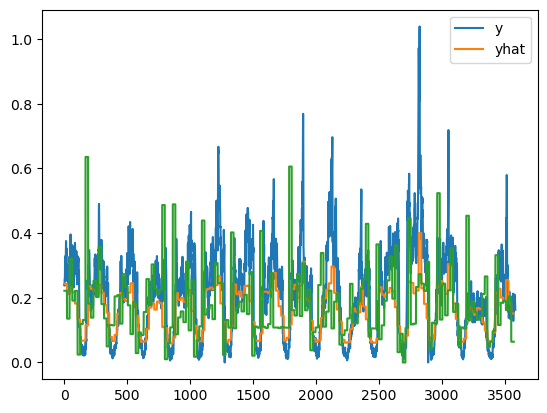

In [40]:
plt.plot(xtest_npy[:,0],label='y')
plt.plot(bbb[:,0],label='yhat')
plt.plot(preds_b2_mean)
plt.legend()

In [32]:
diff = xtest_npy[:len(bbb),0]-bbb[:,0]

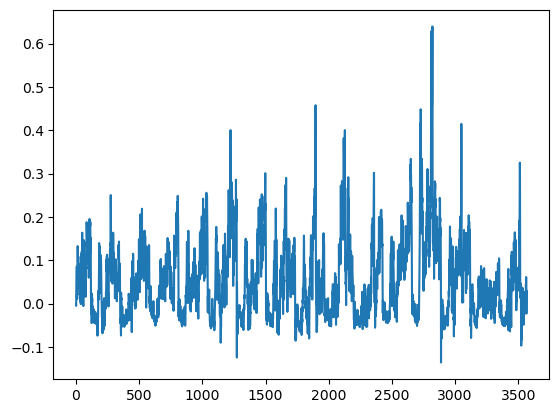

In [33]:
plt.plot(diff)

In [35]:
preds_b2=np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/results_TEST_4_H_mean/Paris/PHI_0.1/Block_2_3_results/ppf_static_0.9_ppf_helper_0.9/Th_21/shared_fore_uncer_block2_delay_21_phi_0.1_alpha_2_gamma_2.npy')

In [38]:
preds_b2_mean=preds_b2.mean(axis=-1)

In [41]:
needed =preds_b2_mean-diff

In [13]:
bbb.dropna(inplace=True)

alignment of the ts

In [14]:
### show the minimum cost of instantiation row
bbb.loc[bbb['Total_Cost'].idxmin()]

Total_Cost               0.730923
Cost_SLA                 0.207717
Cost_Overprovisioning     0.35565
Cost_Instantiation       0.165995
Cost_Reconfiguration     0.001561
Name: Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_0.75_delay_5, dtype: object

In [20]:
bbb.to_csv('../AZTEC_extension/Results_Figs/Paris/total_costs.csv')

In [55]:
bbb

,Total_Cost,Cost_SLA,Cost_Overprovisioning,Cost_Instantiation,Cost_Reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_0.75_delay_33,1.715149,0.256433,1.301296,0.150723,0.006696
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2_delay_33,2.561909,0.610722,1.791792,0.152726,0.006669
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3_delay_33,3.144070,0.875778,2.107057,0.154525,0.006710
Paris_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5_delay_33,4.027593,1.372475,2.492560,0.155848,0.006710
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_0.75_delay_92,1.578326,0.213273,1.168036,0.169500,0.027518
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2_delay_92,2.603203,0.517188,1.886169,0.172322,0.027524
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3_delay_92,3.145367,0.751288,2.193624,0.172890,0.027565
Paris_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5_delay_92,4.021812,1.198660,2.622159,0.173520,0.027473
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_0.75_delay_106,0.878699,0.023405,0.648895,0.204200,0.002198
Paris_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2_delay_106,1.041431,0.061286,0.773692,0.204254,0.002198


In [22]:
aaa=pd.DataFrame(cost_slas_list)

In [20]:
aaa['agg_sla']=aaa.sum(axis=1)

In [23]:
aaa

,0
0,0.103062
1,0.233797
2,0.335753
3,0.53177
4,"[nan, nan, nan, nan, nan]"
5,0.117075
6,0.173728
7,0.279193
8,0.016076
9,0.027744


In [24]:
ccc=pd.concat([aaa,bbb],axis=1)

In [25]:
ccc

,0,Total_Cost
0,0.103062,0.698777
1,0.233797,0.950075
2,0.335753,1.098310
3,0.53177,1.359070
4,"[nan, nan, nan, nan, nan]",NaN
5,0.117075,0.650641
6,0.173728,0.762152
7,0.279193,0.940025
8,0.016076,0.471211
9,0.027744,0.488049


In [15]:
sla_perc_list_index_list

['Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_0.75',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_0.75',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_0.75',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_3',
 'Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_5']

In [16]:
ccc.index=sla_perc_list_index_list

In [17]:
ccc

,0,1,2,3,4,agg_sla,Total_Cost
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_0.75,0.126298,0.107843,0.123414,0.194925,0.070358,0.622837,0.698777
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_2,0.094002,0.076701,0.108997,0.172434,0.055363,0.507497,0.950075
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_3,0.089389,0.075548,0.099769,0.167820,0.050173,0.482699,1.098310
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_0.1_alpha_5,0.092849,0.066897,0.094002,0.160900,0.043253,0.457901,1.359070
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_0.75,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_2,0.073818,0.050750,0.043253,0.084775,0.019608,0.272203,0.650641
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_3,0.072664,0.049596,0.043253,0.083622,0.020761,0.269896,0.762152
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_1_alpha_5,0.070358,0.047866,0.040946,0.081315,0.018454,0.258939,0.940025
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_0.75,0.071511,0.018454,0.022491,0.017301,0.008651,0.138408,0.471211
Bordeaux_ppf_static_0.9_ppf_helper_0.99_phi_10_alpha_2,0.046713,0.009804,0.012111,0.013264,0.006344,0.088235,0.488049


In [20]:
cplus_df=pd.read_csv(f'Results/{city}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')

In [46]:
cost_overprovisioning = np.array([0.18780211, 0.19197072, 0.19877882]) # for different alpha

cost_slas = np.array([0.10121839, 0.07697521, 0.08069174]) # for different alpha

cost_instantiation = np.array([0.35578701, 0.37395105, 0.38364393]) # for different alpha and for eta = 2

cost_reconfiguration = np.array([[0.03507828, 0.03685982, 0.03776066],
       						  [0.3507828 , 0.36859822, 0.37760659],
       						  [3.50782801, 3.68598217, 3.7760659 ]])   # row = phis; column = alphas


In [47]:
block2_shared= np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/Test_lengths/Paris/PHI_0.1/Block_2_3_results/ppf_static_0.9_ppf_helper_0.99/Th_81/shared_fore_uncer_block2_delay_81_phi_0.1_alpha_2_gamma_2.npy')

In [48]:
block2_shared.shape

(3564, 100)

In [50]:
block2_shared_montecarlo = montecarlo_stuff(block2_shared,0.99)

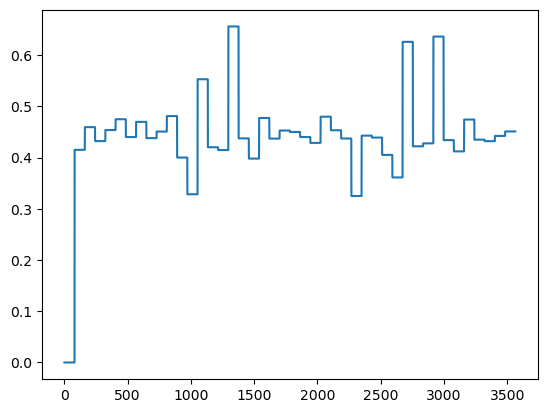

In [51]:
plt.plot(block2_shared_montecarlo)

In [6]:
city='Paris'
bordeaux = pd.read_csv(f'/home/sergi_alcala/sergi_data/AZTEC_extension/citys/{city}.csv')
bordeaux.drop('date_time', axis=1, inplace=True)
bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
bordeaux = bordeaux.to_numpy()

xTrain_size=round(len(bordeaux)*0.7) ### maybe 0.8
xVal_size=round(len(bordeaux)*0.1)
xTest_size=round(len(bordeaux)*0.2)
## Normalize 
# Data
minmaxscaler = MinMaxScaler()
x_train = bordeaux[:xTrain_size]
x_train_norm = tf.convert_to_tensor(minmaxscaler.fit_transform(x_train), dtype=tf.float32)
x_val = bordeaux[xTrain_size:xTrain_size+xVal_size]
x_val_norm_towindow=minmaxscaler.transform(x_val)
x_val_norm = tf.convert_to_tensor(minmaxscaler.transform(x_val), dtype=tf.float32)
x_test = bordeaux[xTrain_size+xVal_size:]
x_test_norm = tf.convert_to_tensor(minmaxscaler.transform(x_test), dtype=tf.float32)

2023-11-30 10:30:40.742643: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79073 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
2023-11-30 10:30:40.744725: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79073 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
2023-11-30 10:30:40.746521: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79073 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0


In [7]:
helper_test=np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/results_TEST_4_H_mean/Paris/helper_forecasting_delay_1.npy')
block2_test=np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/results_TEST_4_H_mean/Paris/PHI_0.1/Block_2_3_results/ppf_static_0.9_ppf_helper_0.9/Th_21/shared_fore_uncer_block2_delay_21_phi_0.1_alpha_2_gamma_2.npy')
block1_test= np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/results_TEST_4_H_mean/Paris/PHI_0.1/Th_21/cap_fore_uncer_test_block1_delay_21_phi_0.1_gamma_2_deltax_005.npy')

In [24]:
x_test_norm_npy=x_test_norm.numpy()

In [27]:
x_test_norm_npy=x_test_norm_npy[12:]

In [11]:
helper_test_mean=helper_test.mean(axis=-2)
block2_test_mean=block2_test.mean(axis=-1)
block1_test_mean=block1_test.mean(axis=-1)

In [29]:
helper_test_mean.shape, block2_test_mean.shape, block1_test_mean.shape,x_test_norm_npy.shape

((3570, 5), (3570,), (3570, 5), (3570, 5))

In [21]:
LOOKBACK=6

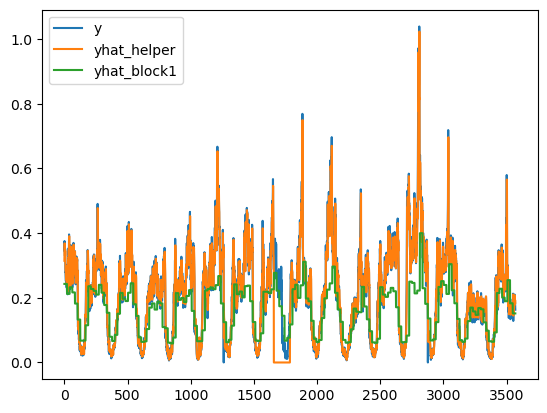

In [46]:

# plt.plot(block2_test_mean[:,0],label='yhat_block2')

In [22]:
helper_test_mean=helper_test_mean[LOOKBACK:]

In [30]:
input_block2 = helper_test_mean-block1_test_mean

In [35]:
diff_block_2= block2_test_mean-input_block2[:,0]

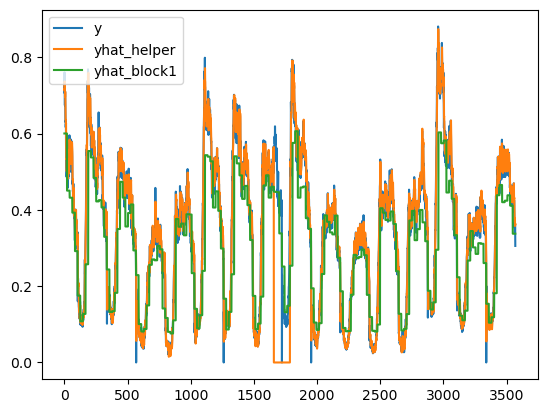

In [49]:
service =2


plt.plot(x_test_norm_npy[:,service],label='y')
plt.plot(helper_test_mean[:,service],label='yhat_helper')
plt.plot(block1_test_mean[:,service],label='yhat_block1')
plt.legend()

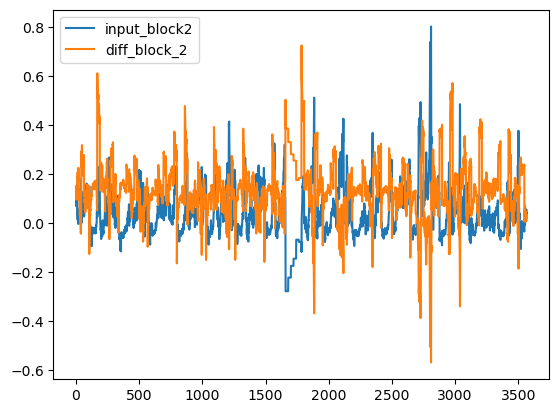

In [37]:
plt.plot(input_block2[:,0],label='input_block2')
plt.plot(diff_block_2,label='diff_block_2')
plt.legend()


In [ ]:
diff=upper_help_test.shape[0]-upper_static_test.shape[0]